# Full Test Without Starting Tree: CPU vs GPU + Kernel Comparison

Comparing IQ-TREE 3.1.0 ModelFinder + tree reconstruction results across 4 workflows **without providing a starting tree** (`-notree`).

**Workflows:**
- **VANILA** — 1 CPU thread (baseline)
- **OMP_10** — 10 OpenMP threads
- **OMP_48** — 48 OpenMP threads (full node)
- **OPENACC** — GPU (V100)

**Kernel variants:** Each workflow is run with both the default kernel (kernel-rev) and `kernelnonrev`.

**Data types:** DNA (GTR+I+G4) and Amino Acid (LG+I+G4), 100 taxa, alignment lengths 100 to 1M sites.

**Key difference from prior tests:** No starting tree is provided — IQ-TREE builds the tree from scratch via BIONJ + NNI search.

In [1]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_BASE = '/Users/u7826985/Projects/Nvidia/results/2026_04_03_fulltets_withouttree'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_04_03_fulltets_withouttree'

# Backend labels
backend_labels = {
    'VANILA': '1 CPU thread',
    'OMP_10': '10 CPU threads',
    'OMP_48': '48 CPU threads',
    'OPENACC': 'GPU (V100)'
}
backend_order = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']

# Kernel labels
kernel_labels = {'default': 'Kernel-Rev', 'kernelnonrev': 'Kernel-NonRev'}

# Workflow colors (for CPU vs GPU comparison)
wf_colors = {'1 CPU thread': '#1f77b4', '10 CPU threads': '#ff7f0e', '48 CPU threads': '#2ca02c', 'GPU (V100)': '#d62728'}
wf_markers = {'1 CPU thread': 'o', '10 CPU threads': 's', '48 CPU threads': '^', 'GPU (V100)': 'D'}

# Kernel colors (for kernel comparison)
kernel_colors = {'Kernel-Rev': '#2ca02c', 'Kernel-NonRev': '#d62728'}

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

## 1. Data Loading and Parsing

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))

    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))

    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))

    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    return data

def parse_model_table(filepath):
    """Parse the 'List of models sorted by BIC scores' table from .iqtree file."""
    models = []
    with open(filepath, 'r') as f:
        content = f.read()

    table_match = re.search(r'Model\s+LogL\s+AIC.*?BIC.*?\n(.*?)(?:\n\n|\nAkaike|\nBayesian)', content, re.DOTALL)
    if not table_match:
        return models

    for line in table_match.group(1).strip().split('\n'):
        line = line.strip()
        if not line or line.startswith('---'):
            continue
        parts = line.split()
        if len(parts) >= 9:
            try:
                model_name = parts[0]
                lnl = float(parts[1])
                aic = float(parts[2])
                bic = float(parts[-3])
                models.append({'model': model_name, 'lnL': lnl, 'AIC': aic, 'BIC': bic})
            except (ValueError, IndexError):
                continue
    return models

def load_all_results():
    """Load results for both kernel types, both data types, all backends."""
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    data_types = ['DNA', 'AA']

    for data_type in data_types:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir):
                continue

            all_iqtree = glob.glob(os.path.join(len_dir, '*.iqtree'))
            all_log = glob.glob(os.path.join(len_dir, '*.log'))

            for backend in backends:
                for kernel_key in ['default', 'kernelnonrev']:
                    # Build file pattern
                    if kernel_key == 'kernelnonrev':
                        iqtree_files = [f for f in all_iqtree if f'_kernelnonrev_' in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]
                        log_files = [f for f in all_log if f'_kernelnonrev_' in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]
                    else:
                        iqtree_files = [f for f in all_iqtree if '_kernelnonrev_' not in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]
                        log_files = [f for f in all_log if '_kernelnonrev_' not in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]

                    if iqtree_files:
                        data = parse_iqtree_file(iqtree_files[0])
                    elif log_files:
                        data = parse_log_file(log_files[0])
                    else:
                        continue

                    if not data or 'wall_time_sec' not in data:
                        continue

                    data['length'] = length
                    data['kernel'] = kernel_key
                    data['kernel_label'] = kernel_labels[kernel_key]
                    data['backend'] = backend
                    data['backend_label'] = backend_labels[backend]
                    data['data_type'] = data_type
                    records.append(data)

    return pd.DataFrame(records)

def load_model_details(data_type, lengths_to_use, kernel_key=None):
    """Load per-model results for detailed comparison."""
    all_model_records = []
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']

    for length in lengths_to_use:
        len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
        if not os.path.isdir(len_dir):
            continue
        all_iqtree = glob.glob(os.path.join(len_dir, '*.iqtree'))

        for backend in backends:
            kernels = [kernel_key] if kernel_key else ['default', 'kernelnonrev']
            for kk in kernels:
                if kk == 'kernelnonrev':
                    files = [f for f in all_iqtree if '_kernelnonrev_' in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]
                else:
                    files = [f for f in all_iqtree if '_kernelnonrev_' not in os.path.basename(f) and f'_{backend}_' in os.path.basename(f)]

                if not files:
                    continue
                models = parse_model_table(files[0])
                for m in models:
                    m['length'] = length
                    m['backend'] = backend
                    m['backend_label'] = backend_labels[backend]
                    m['kernel'] = kk
                    m['kernel_label'] = kernel_labels[kk]
                    all_model_records.append(m)

    return pd.DataFrame(all_model_records)

# Load all results
df = load_all_results()
print(f"Total records parsed: {len(df)}")
print(f"\nData types: {sorted(df['data_type'].unique())}")
print(f"Kernels: {sorted(df['kernel_label'].unique())}")
print(f"Backends: {sorted(df['backend_label'].unique())}")
print(f"Lengths: {sorted(df['length'].unique())}")

df_dna = df[df['data_type'] == 'DNA'].copy()
df_aa = df[df['data_type'] == 'AA'].copy()
print(f"\nDNA records: {len(df_dna)}, AA records: {len(df_aa)}")

# Also create subsets for default kernel only (for CPU vs GPU comparison)
df_dna_rev = df_dna[df_dna['kernel_label'] == 'Kernel-Rev'].copy()
df_aa_rev = df_aa[df_aa['kernel_label'] == 'Kernel-Rev'].copy()
df_dna_nonrev = df_dna[df_dna['kernel_label'] == 'Kernel-NonRev'].copy()
df_aa_nonrev = df_aa[df_aa['kernel_label'] == 'Kernel-NonRev'].copy()

Total records parsed: 68

Data types: ['AA', 'DNA']
Kernels: ['Kernel-NonRev', 'Kernel-Rev']
Backends: ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']
Lengths: [100, 1000, 10000, 100000, 1000000]

DNA records: 38, AA records: 30


In [3]:
# Full summary table
display_cols = ['data_type', 'length', 'kernel_label', 'backend_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
summary = df[display_cols].sort_values(['data_type', 'length', 'backend_label', 'kernel_label']).reset_index(drop=True)
summary['wall_time_fmt'] = summary['wall_time_sec'].apply(fmt_time)
summary['cpu_time_fmt'] = summary['cpu_time_sec'].apply(fmt_time)
print(f"Full results summary ({len(summary)} runs):")
summary

Full results summary (68 runs):


,data_type,length,kernel_label,backend_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec,wall_time_fmt,cpu_time_fmt
0,AA,100,Kernel-NonRev,1 CPU thread,LG+G4,-7.670271e+03,679.9740,678.4740,11.3m,11.3m
1,AA,100,Kernel-Rev,1 CPU thread,LG+G4,-7.670271e+03,154.8040,154.2120,2.6m,2.6m
2,AA,100,Kernel-NonRev,10 CPU threads,LG+G4,-7.670271e+03,462.2040,4569.0100,7.7m,1.3h
3,AA,100,Kernel-Rev,10 CPU threads,LG+G4,-7.670271e+03,181.8700,1148.4600,3.0m,19.1m
4,AA,100,Kernel-NonRev,48 CPU threads,LG+G4,-7.670271e+03,465.5760,5516.9600,7.8m,1.5h
...,...,...,...,...,...,...,...,...,...,...
63,DNA,1000000,Kernel-Rev,10 CPU threads,F81+F+G4,-5.920802e+07,29249.8340,264218.4400,8.1h,73.4h
64,DNA,1000000,Kernel-NonRev,48 CPU threads,F81+F+G4,-5.920802e+07,18850.7140,790471.2600,5.2h,219.6h
65,DNA,1000000,Kernel-Rev,48 CPU threads,F81+F+G4,-5.920802e+07,16874.4970,698178.1900,4.7h,193.9h
66,DNA,1000000,Kernel-NonRev,GPU (V100),F81+F+G4,-5.920802e+07,9569.1667,9515.2598,2.7h,2.6h


---
# Part 1: DNA Analysis — CPU vs GPU (Kernel-Rev)

Using the default (kernel-rev) results for the primary CPU vs GPU comparison.

## 2. Model Selection Agreement (DNA)

In [4]:
df = df_dna_rev.copy()

# Check if all workflows select the same model for each alignment length
model_pivot = df.pivot_table(index='length', columns='backend_label', values='best_model', aggfunc='first')
model_pivot = model_pivot[[c for c in backend_order if c in model_pivot.columns]]

print("Model Selection by Workflow (DNA, Kernel-Rev):")
print("=" * 80)
display(model_pivot)

# Check agreement
for length in model_pivot.index:
    models = model_pivot.loc[length].dropna().unique()
    status = "AGREE" if len(models) == 1 else "DISAGREE"
    print(f"  Length {length:>10,}: {status} — {', '.join(models)}")

Model Selection by Workflow (DNA, Kernel-Rev):


backend_label,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,F81+F+ASC+G4,F81+F+ASC+G4,F81+F+ASC+G4,F81+F+ASC+G4
1000,F81+F+G4,F81+F+G4,F81+F+G4,F81+F+G4
10000,F81+F+G4,F81+F+G4,F81+F+G4,F81+F+G4
100000,F81+F+G4,F81+F+G4,F81+F+G4,F81+F+G4
1000000,NaN,F81+F+G4,F81+F+G4,F81+F+G4


  Length        100: AGREE — F81+F+ASC+G4
  Length      1,000: AGREE — F81+F+G4
  Length     10,000: AGREE — F81+F+G4
  Length    100,000: AGREE — F81+F+G4
  Length  1,000,000: AGREE — F81+F+G4


### Model Selection & Log-Likelihood Heatmap (DNA)

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_76846/2898527913.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_m = plt.cm.get_cmap('tab10', len(all_models))


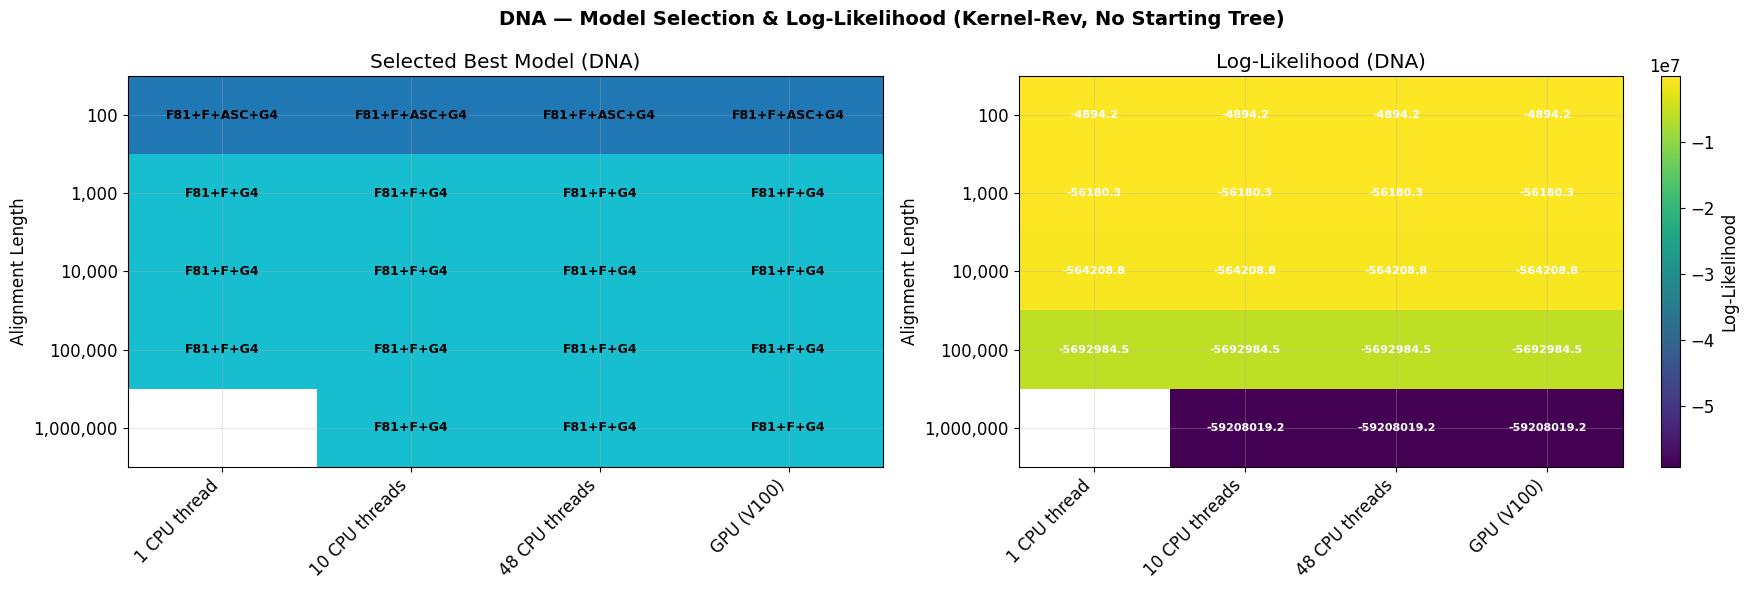

In [5]:
# --- 1. Selected Model Heatmap ---
model_pivot = df.pivot_table(index='length', columns='backend_label', values='best_model', aggfunc='first')
model_pivot = model_pivot[[c for c in backend_order if c in model_pivot.columns]]

# Encode models as integers for heatmap
all_models = sorted(model_pivot.stack().unique())
model_to_int = {m: i for i, m in enumerate(all_models)}
model_encoded = model_pivot.applymap(lambda x: model_to_int.get(x, -1) if pd.notna(x) else np.nan)

# --- 2. Log-Likelihood Heatmap ---
lnl_pivot = df.pivot_table(index='length', columns='backend_label', values='log_likelihood', aggfunc='first')
lnl_pivot = lnl_pivot[[c for c in backend_order if c in lnl_pivot.columns]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Model heatmap
cmap_m = plt.cm.get_cmap('tab10', len(all_models))
im1 = ax1.imshow(model_encoded.values, cmap=cmap_m, aspect='auto', vmin=-0.5, vmax=len(all_models)-0.5)
ax1.set_xticks(range(len(model_encoded.columns)))
ax1.set_xticklabels(model_encoded.columns, rotation=45, ha='right')
ax1.set_yticks(range(len(model_encoded.index)))
ax1.set_yticklabels([f'{l:,}' for l in model_encoded.index])
ax1.set_ylabel('Alignment Length')
ax1.set_title('Selected Best Model (DNA)')
for i in range(len(model_encoded.index)):
    for j in range(len(model_encoded.columns)):
        val = model_pivot.iloc[i, j]
        if pd.notna(val):
            ax1.text(j, i, val, ha='center', va='center', fontsize=9, fontweight='bold')

# lnL heatmap
im2 = ax2.imshow(lnl_pivot.values, cmap='viridis', aspect='auto')
ax2.set_xticks(range(len(lnl_pivot.columns)))
ax2.set_xticklabels(lnl_pivot.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(lnl_pivot.index)))
ax2.set_yticklabels([f'{l:,}' for l in lnl_pivot.index])
ax2.set_ylabel('Alignment Length')
ax2.set_title('Log-Likelihood (DNA)')
for i in range(len(lnl_pivot.index)):
    for j in range(len(lnl_pivot.columns)):
        val = lnl_pivot.iloc[i, j]
        if pd.notna(val):
            ax2.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
plt.colorbar(im2, ax=ax2, label='Log-Likelihood')

plt.suptitle('DNA — Model Selection & Log-Likelihood (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'model_likelihood_heatmap_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Model Log-Likelihood Comparison (DNA)

In [6]:
# Load per-model data for DNA (default kernel only)
dna_lengths = sorted(df_dna_rev['length'].unique())
model_df_dna = load_model_details('DNA', dna_lengths, kernel_key='default')
print(f"Parsed {len(model_df_dna)} per-model records across {model_df_dna['length'].nunique()} lengths")

# Per-model lnL comparison: compute max |diff| across workflows
lnl_pivot_dna = df_dna_rev.pivot_table(index='length', columns='backend_label', values='log_likelihood', aggfunc='first')
lnl_pivot_dna = lnl_pivot_dna[[c for c in backend_order if c in lnl_pivot_dna.columns]]

print("\nLog-Likelihood by Workflow (DNA, Kernel-Rev):")
print("=" * 80)
display(lnl_pivot_dna)

# Compute max absolute difference across workflows at each length
lnl_pivot_dna['max_abs_diff'] = lnl_pivot_dna.apply(lambda row: row.dropna().max() - row.dropna().min(), axis=1)
print("\nMax |lnL diff| across workflows:")
for length, diff in lnl_pivot_dna['max_abs_diff'].items():
    print(f"  Length {length:>10,}: {diff:.4f}")

Parsed 1862 per-model records across 5 lengths

Log-Likelihood by Workflow (DNA, Kernel-Rev):


backend_label,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,-4.894189e+03,-4.894189e+03,-4.894189e+03,-4.894189e+03
1000,-5.618029e+04,-5.618029e+04,-5.618029e+04,-5.618029e+04
10000,-5.642088e+05,-5.642088e+05,-5.642088e+05,-5.642088e+05
100000,-5.692985e+06,-5.692985e+06,-5.692985e+06,-5.692985e+06
1000000,NaN,-5.920802e+07,-5.920802e+07,-5.920802e+07



Max |lnL diff| across workflows:
  Length        100: 0.0004
  Length      1,000: 0.0001
  Length     10,000: 0.0001
  Length    100,000: 0.0000
  Length  1,000,000: 0.0000


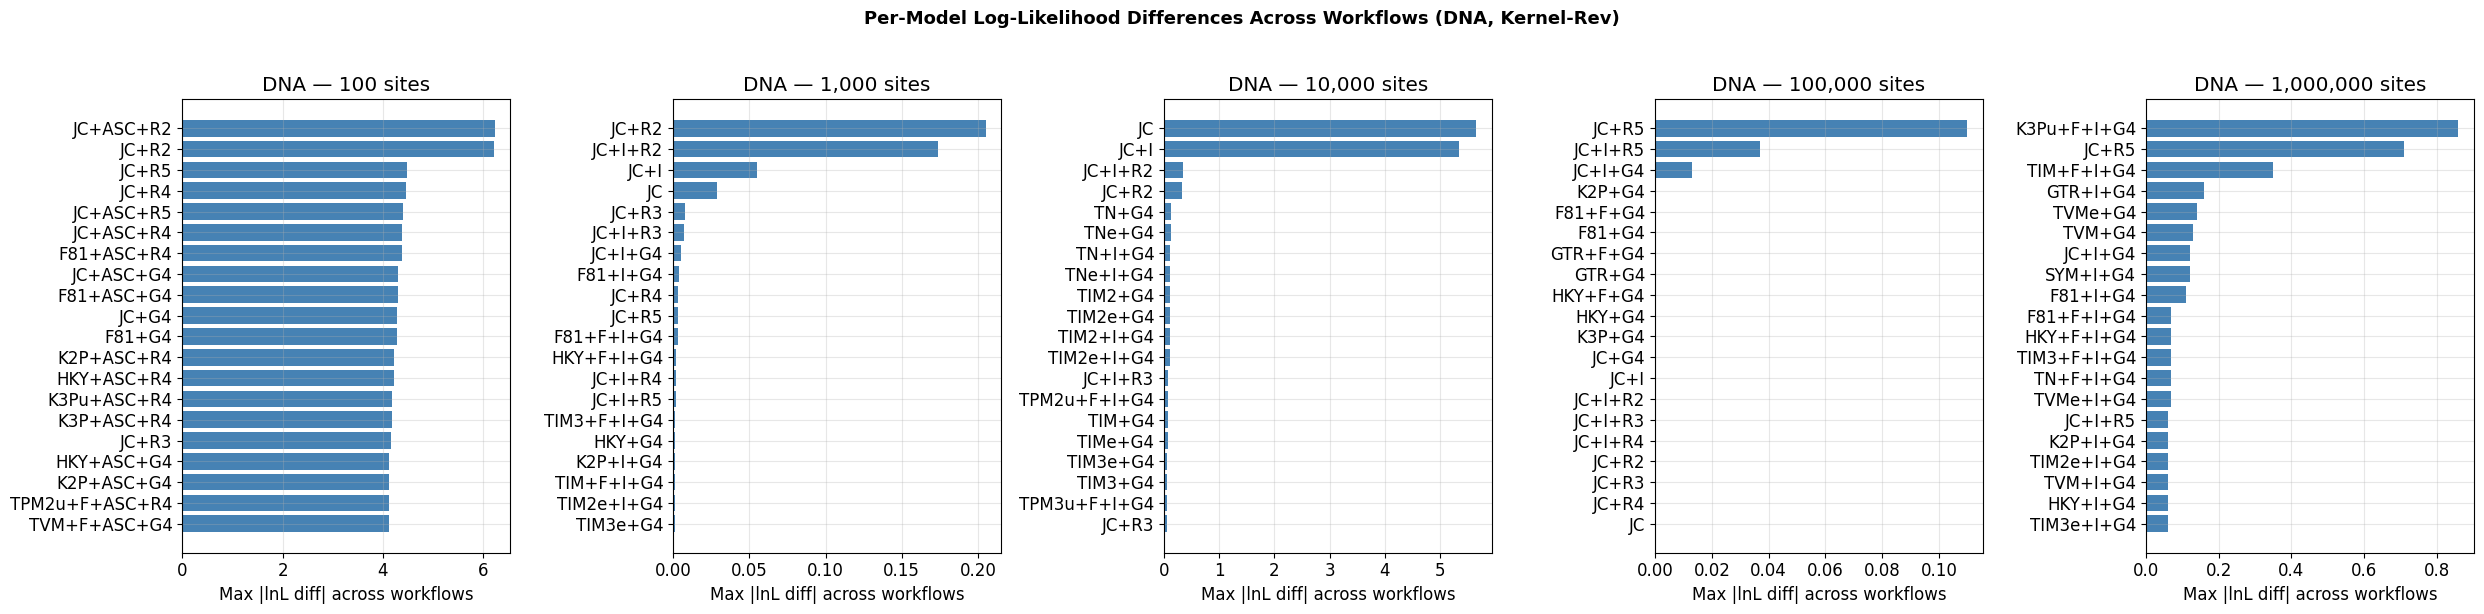

In [7]:
# Per-model lnL difference plot (DNA)
if len(model_df_dna) > 0:
    # For each length, compare per-model lnL across workflows
    comp_records = []
    for length in dna_lengths:
        sub = model_df_dna[model_df_dna['length'] == length]
        if sub.empty: continue
        lnl_by_model = sub.pivot_table(index='model', columns='backend_label', values='lnL', aggfunc='first')
        if lnl_by_model.shape[1] < 2: continue
        lnl_by_model['max_diff'] = lnl_by_model.apply(lambda r: r.dropna().max() - r.dropna().min(), axis=1)
        top = lnl_by_model.nlargest(20, 'max_diff')
        for model_name in top.index:
            comp_records.append({'length': length, 'model': model_name, 'max_diff': top.loc[model_name, 'max_diff']})

    comp_df_dna = pd.DataFrame(comp_records)

    n_lengths = comp_df_dna['length'].nunique()
    if n_lengths > 0:
        fig, axes = plt.subplots(1, n_lengths, figsize=(5*n_lengths, 6), sharey=False)
        if n_lengths == 1: axes = [axes]
        for ax, length in zip(axes, sorted(comp_df_dna['length'].unique())):
            sub = comp_df_dna[comp_df_dna['length'] == length].sort_values('max_diff', ascending=True)
            ax.barh(sub['model'], sub['max_diff'], color='steelblue')
            ax.set_xlabel('Max |lnL diff| across workflows')
            ax.set_title(f'DNA — {length:,} sites')
            ax.grid(axis='x', alpha=0.3)
        plt.suptitle('Per-Model Log-Likelihood Differences Across Workflows (DNA, Kernel-Rev)', fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'per_model_lnl_differences_DNA.png'), dpi=150, bbox_inches='tight')
        plt.show()

## 4. Wall-Clock Runtime Comparison (DNA)

In [8]:
time_pivot_dna = df_dna_rev.pivot_table(index='length', columns='backend_label', values='wall_time_sec', aggfunc='first')
time_pivot_dna = time_pivot_dna[[c for c in backend_order if c in time_pivot_dna.columns]]

print("Wall-Clock Time (seconds) — DNA, Kernel-Rev:")
print("=" * 80)
fmt_pivot = time_pivot_dna.copy()
for col in fmt_pivot.columns:
    fmt_pivot[col] = fmt_pivot[col].apply(fmt_time)
display(fmt_pivot)

Wall-Clock Time (seconds) — DNA, Kernel-Rev:


backend_label,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,21.3s,1.8m,4.6m,8.0m
1000,1.4m,47.6s,4.3m,4.9m
10000,15.0m,3.9m,4.9m,5.6m
100000,2.6h,23.8m,16.1m,16.4m
1000000,N/A,8.1h,4.7h,2.7h


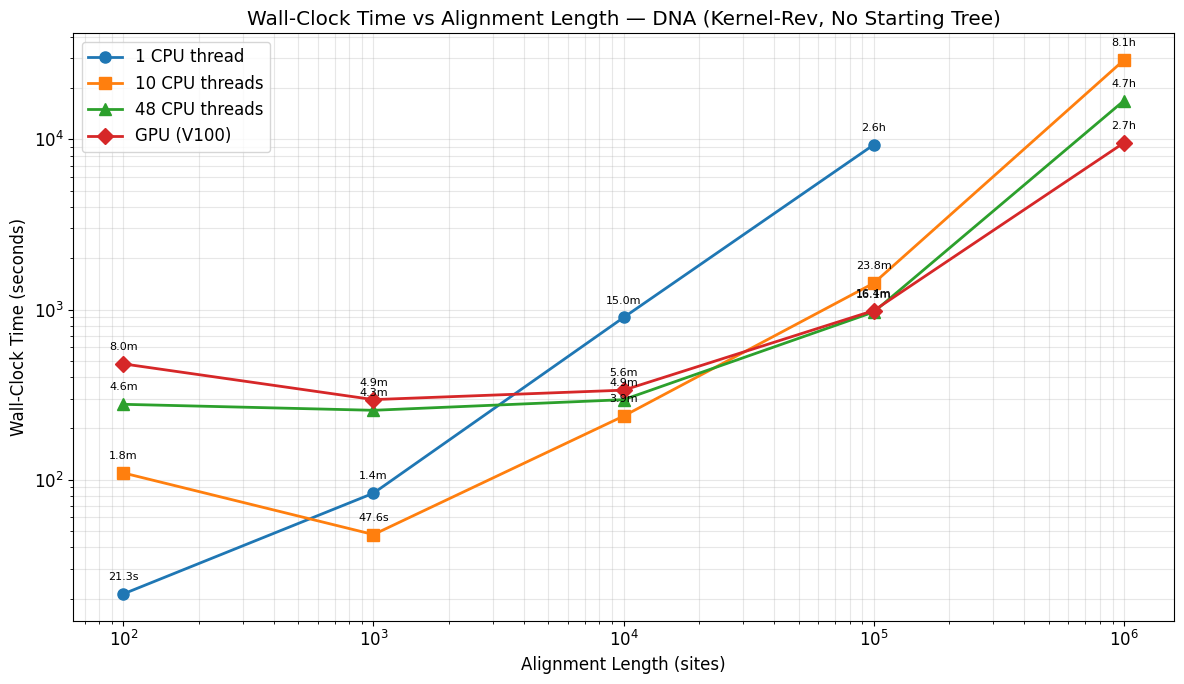

In [9]:
# Wall-clock time line plot (DNA)
fig, ax = plt.subplots(figsize=(12, 7))
available_wfs = [c for c in backend_order if c in time_pivot_dna.columns]
for wf in available_wfs:
    data = time_pivot_dna[wf].dropna()
    ax.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
            label=wf, linewidth=2, markersize=8)
    for x, y in zip(data.index, data.values):
        ax.annotate(fmt_time(y), (x, y), textcoords='offset points', xytext=(0, 10),
                    fontsize=8, ha='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)')
ax.set_ylabel('Wall-Clock Time (seconds)')
ax.set_title('Wall-Clock Time vs Alignment Length — DNA (Kernel-Rev, No Starting Tree)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

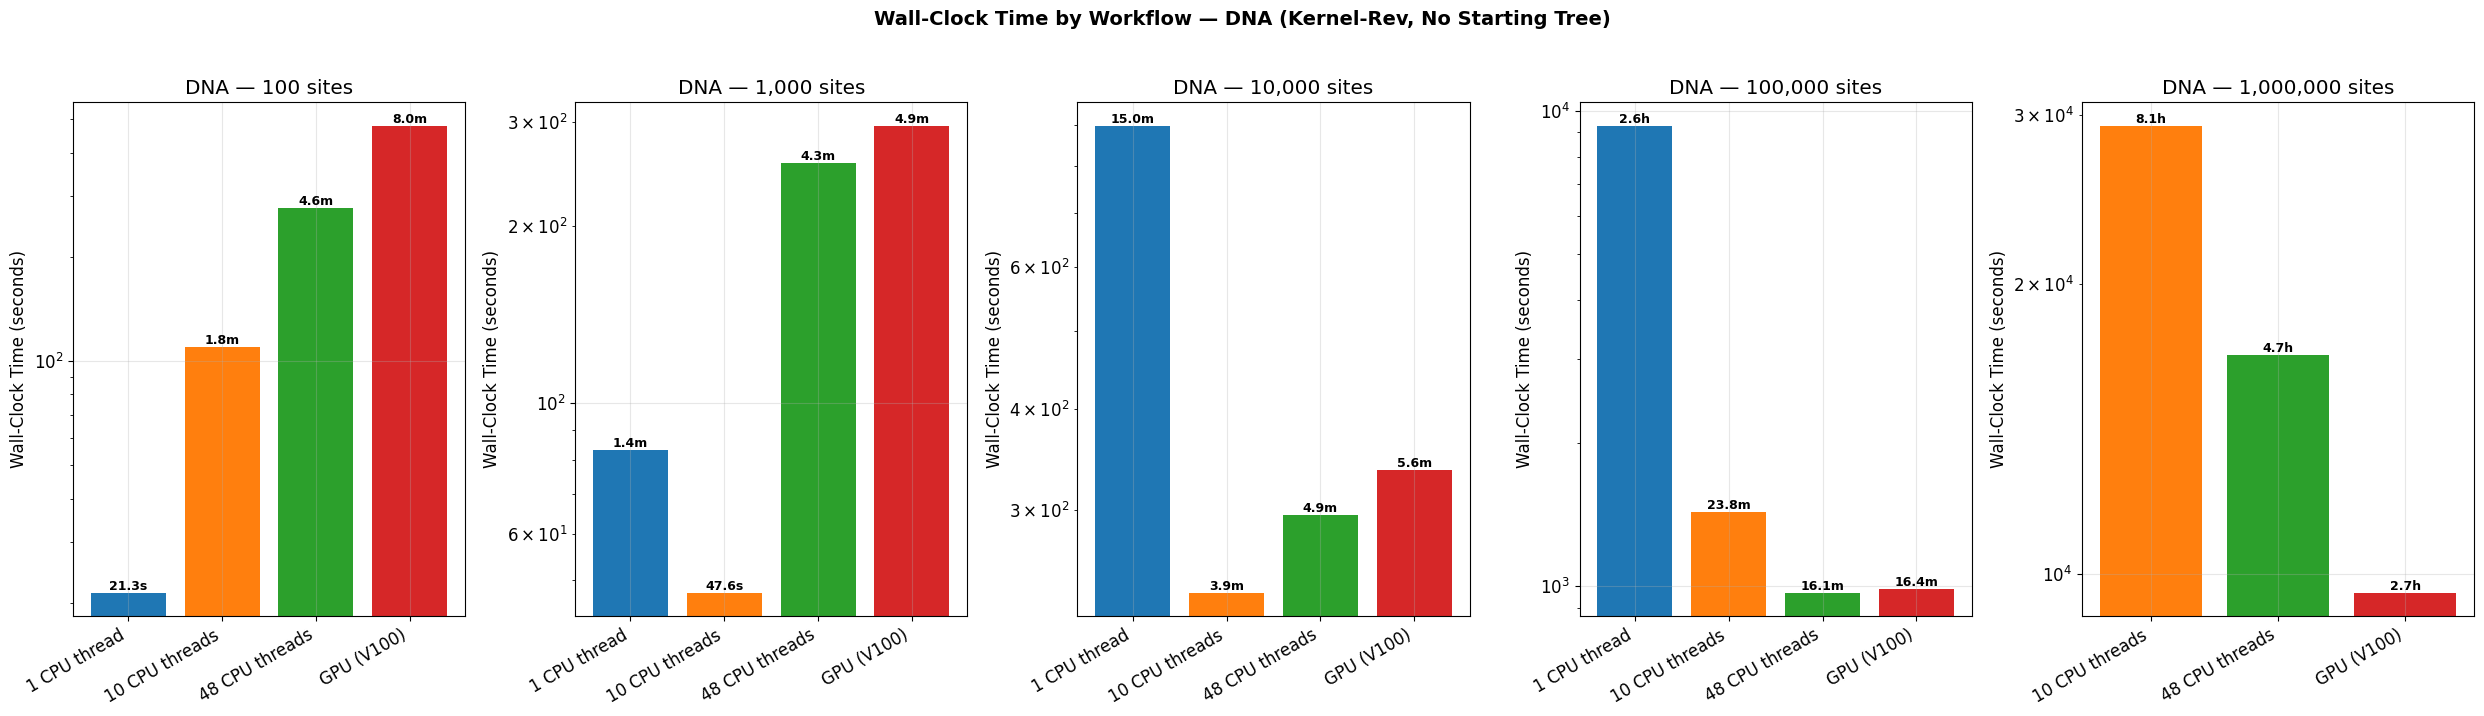

In [10]:
# Bar chart for wall-clock time at each alignment length (DNA)
valid_lengths = time_pivot_dna.dropna(thresh=2).index

fig, axes = plt.subplots(1, len(valid_lengths), figsize=(5*len(valid_lengths), 7), sharey=False)
if len(valid_lengths) == 1: axes = [axes]

for ax, length in zip(axes, valid_lengths):
    wfs_present = [c for c in backend_order if c in time_pivot_dna.columns and pd.notna(time_pivot_dna.loc[length, c])]
    times = [time_pivot_dna.loc[length, wf] for wf in wfs_present]
    bar_colors = [wf_colors[wf] for wf in wfs_present]
    bars = ax.bar(range(len(wfs_present)), times, color=bar_colors)
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(t),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(wfs_present)))
    ax.set_xticklabels(wfs_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'DNA — {length:,} sites')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time by Workflow — DNA (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Analysis (DNA)

Speedup vs 1 CPU thread (DNA, Kernel-Rev):


,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,1.0,0.19,0.08,0.04
1000,1.0,1.75,0.33,0.28
10000,1.0,3.80,3.04,2.67
100000,1.0,6.51,9.61,9.43
1000000,NaN,NaN,NaN,NaN


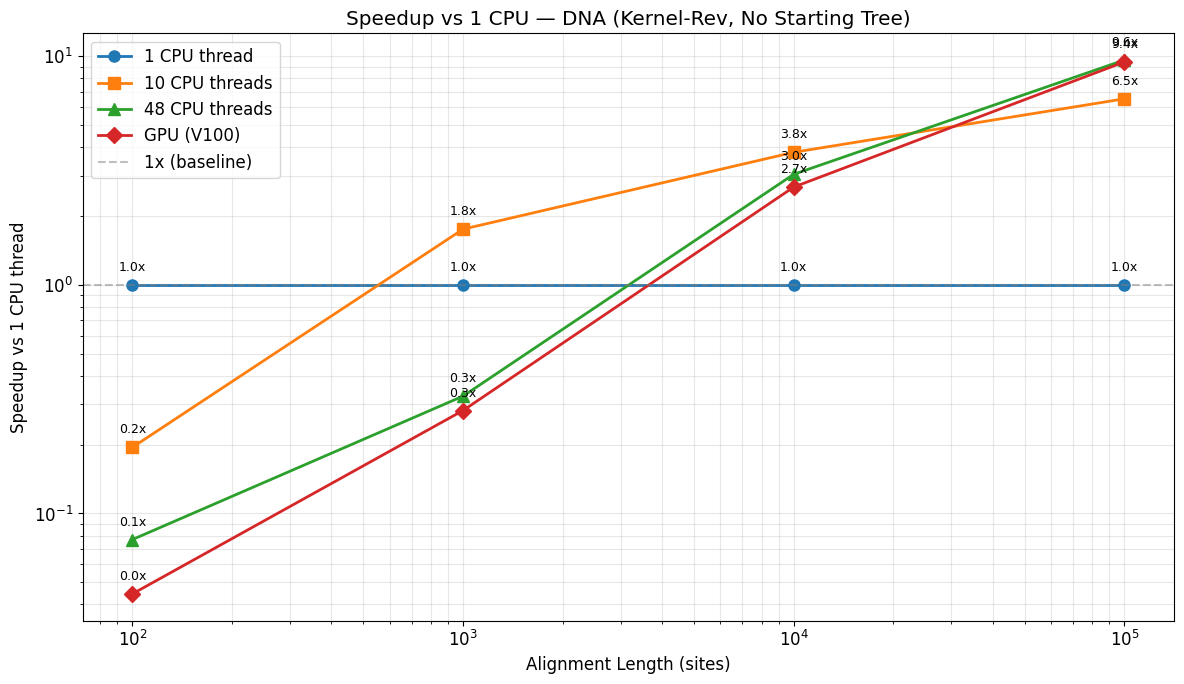

In [11]:
if '1 CPU thread' in time_pivot_dna.columns:
    speedup_df_dna = pd.DataFrame(index=time_pivot_dna.index)
    for wf in available_wfs:
        speedup_df_dna[wf] = time_pivot_dna['1 CPU thread'] / time_pivot_dna[wf]

    print("Speedup vs 1 CPU thread (DNA, Kernel-Rev):")
    print("=" * 80)
    display(speedup_df_dna.round(2))

    # Speedup plot
    fig, ax = plt.subplots(figsize=(12, 7))
    for wf in [c for c in backend_order if c in speedup_df_dna.columns]:
        data = speedup_df_dna[wf].dropna()
        ax.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
                label=wf, linewidth=2, markersize=8)
        for x, y in zip(data.index, data.values):
            ax.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 10),
                        fontsize=9, ha='center')

    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='1x (baseline)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Speedup vs 1 CPU thread')
    ax.set_title('Speedup vs 1 CPU — DNA (Kernel-Rev, No Starting Tree)')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu_DNA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison (DNA)

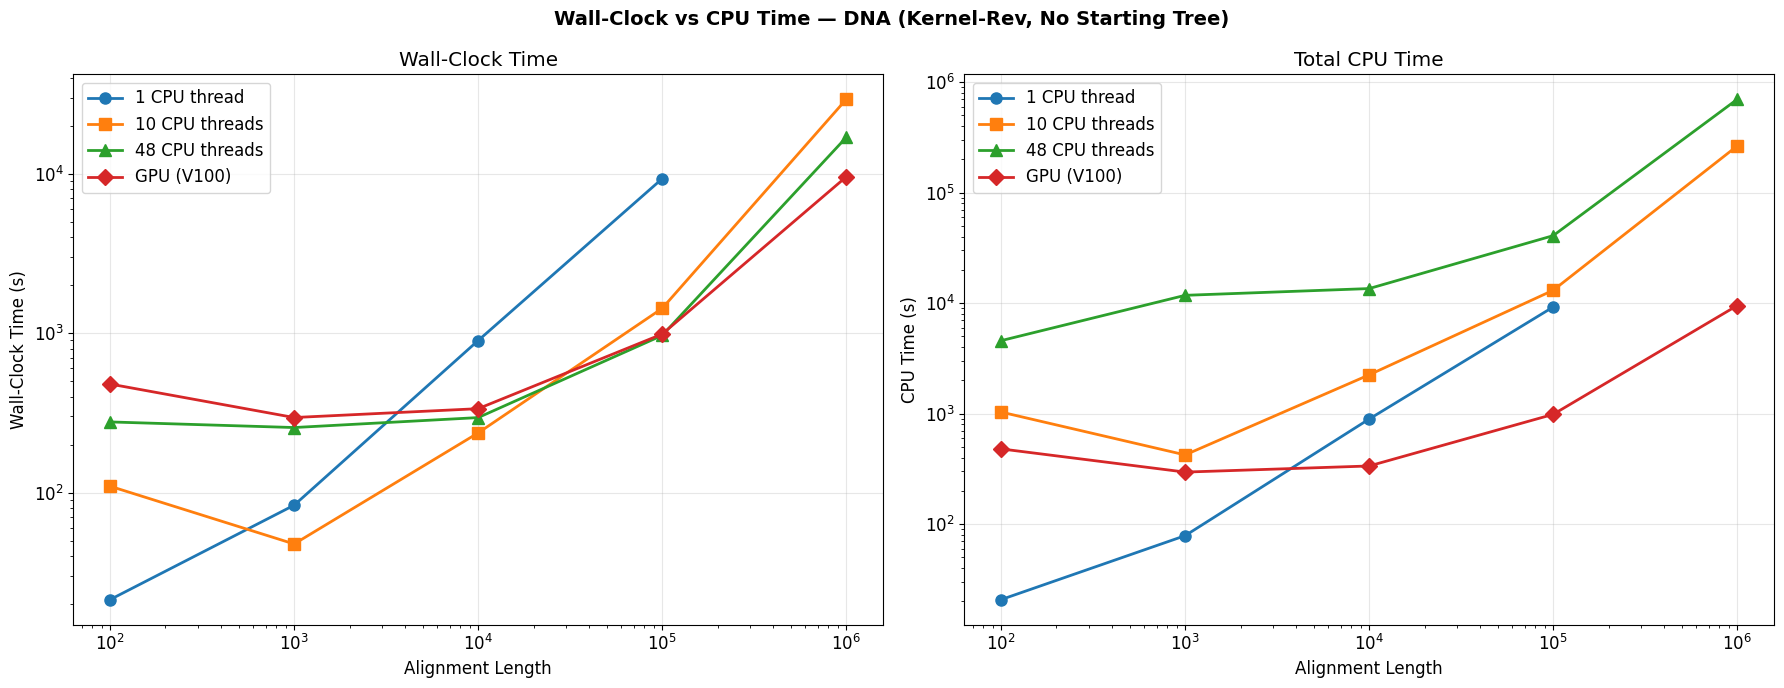

In [12]:
cpu_pivot_dna = df_dna_rev.pivot_table(index='length', columns='backend_label', values='cpu_time_sec', aggfunc='first')
cpu_pivot_dna = cpu_pivot_dna[[c for c in backend_order if c in cpu_pivot_dna.columns]]

# Wall vs CPU time comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for wf in [c for c in backend_order if c in time_pivot_dna.columns]:
    wall = time_pivot_dna[wf].dropna()
    ax1.plot(wall.index, wall.values, marker=wf_markers[wf], color=wf_colors[wf],
             label=wf, linewidth=2, markersize=8)

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length'); ax1.set_ylabel('Wall-Clock Time (s)')
ax1.set_title('Wall-Clock Time'); ax1.legend(); ax1.grid(True, alpha=0.3)

for wf in [c for c in backend_order if c in cpu_pivot_dna.columns]:
    cpu = cpu_pivot_dna[wf].dropna()
    ax2.plot(cpu.index, cpu.values, marker=wf_markers[wf], color=wf_colors[wf],
             label=wf, linewidth=2, markersize=8)

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length'); ax2.set_ylabel('CPU Time (s)')
ax2.set_title('Total CPU Time'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Wall-Clock vs CPU Time — DNA (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_vs_cpu_time_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary: GPU vs CPU (DNA)

GPU Speedup Summary — DNA (Kernel-Rev, No Starting Tree)


,Sites,GPU,vs 1 CPU thread,vs 10 CPU threads,vs 48 CPU threads
0,100,8.0m,0.04x slower,0.23x slower,0.58x slower
1,"1,000",4.9m,0.28x slower,0.16x slower,0.87x slower
2,"10,000",5.6m,2.67x faster,0.70x slower,0.88x slower
3,"100,000",16.4m,9.43x faster,1.45x faster,0.98x slower
4,"1,000,000",2.7h,N/A,3.06x faster,1.77x faster


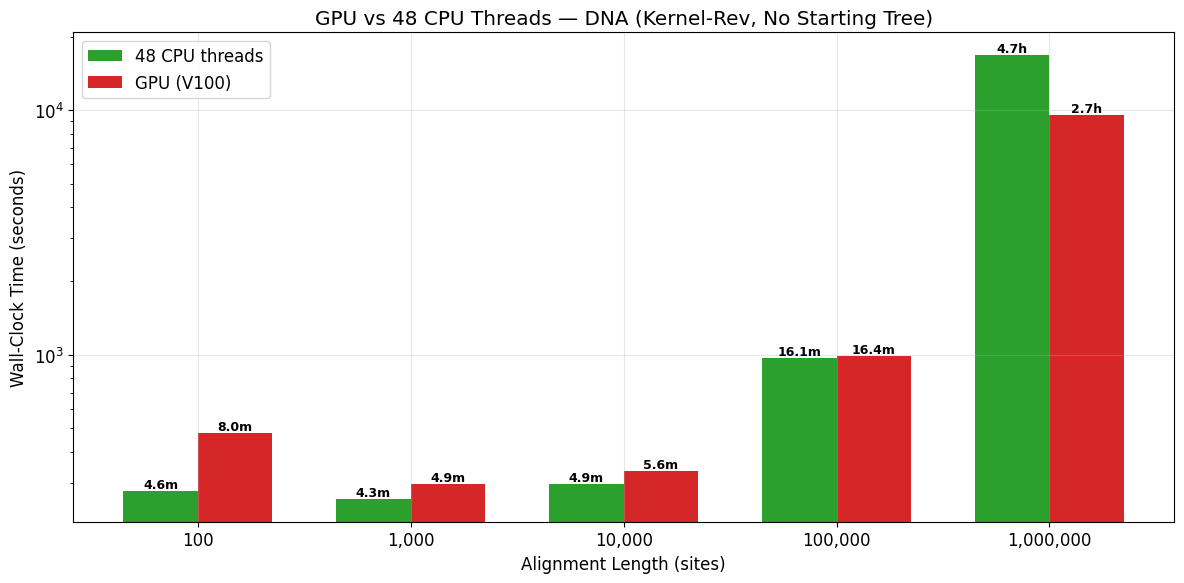

In [13]:
if 'GPU (V100)' in time_pivot_dna.columns:
    summary_rows = []
    for length in time_pivot_dna.index:
        gpu_time = time_pivot_dna.loc[length, 'GPU (V100)']
        row = {'Sites': f'{length:,}', 'GPU': fmt_time(gpu_time)}
        for wf in ['1 CPU thread', '10 CPU threads', '48 CPU threads']:
            if wf in time_pivot_dna.columns:
                cpu_time = time_pivot_dna.loc[length, wf]
                if pd.notna(cpu_time) and pd.notna(gpu_time):
                    ratio = cpu_time / gpu_time
                    row[f'vs {wf}'] = f'{ratio:.2f}x {"faster" if ratio > 1 else "slower"}'
                else:
                    row[f'vs {wf}'] = 'N/A'
        summary_rows.append(row)
    gpu_summary_dna = pd.DataFrame(summary_rows)
    print("GPU Speedup Summary — DNA (Kernel-Rev, No Starting Tree)")
    print("=" * 100)
    display(gpu_summary_dna)

# GPU vs 48 CPU bar chart
if 'GPU (V100)' in time_pivot_dna.columns and '48 CPU threads' in time_pivot_dna.columns:
    common_lengths = time_pivot_dna.dropna(subset=['GPU (V100)', '48 CPU threads']).index
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(common_lengths))
    width = 0.35
    gpu_times = [time_pivot_dna.loc[l, 'GPU (V100)'] for l in common_lengths]
    cpu48_times = [time_pivot_dna.loc[l, '48 CPU threads'] for l in common_lengths]
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPU threads', color=wf_colors['48 CPU threads'])
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=wf_colors['GPU (V100)'])
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in common_lengths])
    ax.set_xlabel('Alignment Length (sites)')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title('GPU vs 48 CPU Threads — DNA (Kernel-Rev, No Starting Tree)')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars_DNA.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 2: Amino Acid Analysis — CPU vs GPU (Kernel-Rev)

## 8. Model Selection Agreement (AA)

In [14]:
df = df_aa_rev.copy()

model_pivot_aa = df.pivot_table(index='length', columns='backend_label', values='best_model', aggfunc='first')
model_pivot_aa = model_pivot_aa[[c for c in backend_order if c in model_pivot_aa.columns]]

print("Model Selection by Workflow (AA, Kernel-Rev):")
print("=" * 80)
display(model_pivot_aa)

for length in model_pivot_aa.index:
    models = model_pivot_aa.loc[length].dropna().unique()
    status = "AGREE" if len(models) == 1 else "DISAGREE"
    print(f"  Length {length:>10,}: {status} — {', '.join(models)}")

Model Selection by Workflow (AA, Kernel-Rev):


backend_label,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,LG+G4,LG+G4,LG+G4,LG+G4
1000,LG+G4,LG+G4,LG+G4,LG+G4
10000,LG+G4,LG+G4,LG+G4,LG+G4
100000,NaN,LG+G4,LG+G4,LG+G4


  Length        100: AGREE — LG+G4
  Length      1,000: AGREE — LG+G4
  Length     10,000: AGREE — LG+G4
  Length    100,000: AGREE — LG+G4


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_76846/3410032735.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_m = plt.cm.get_cmap('tab10', len(all_models_aa))


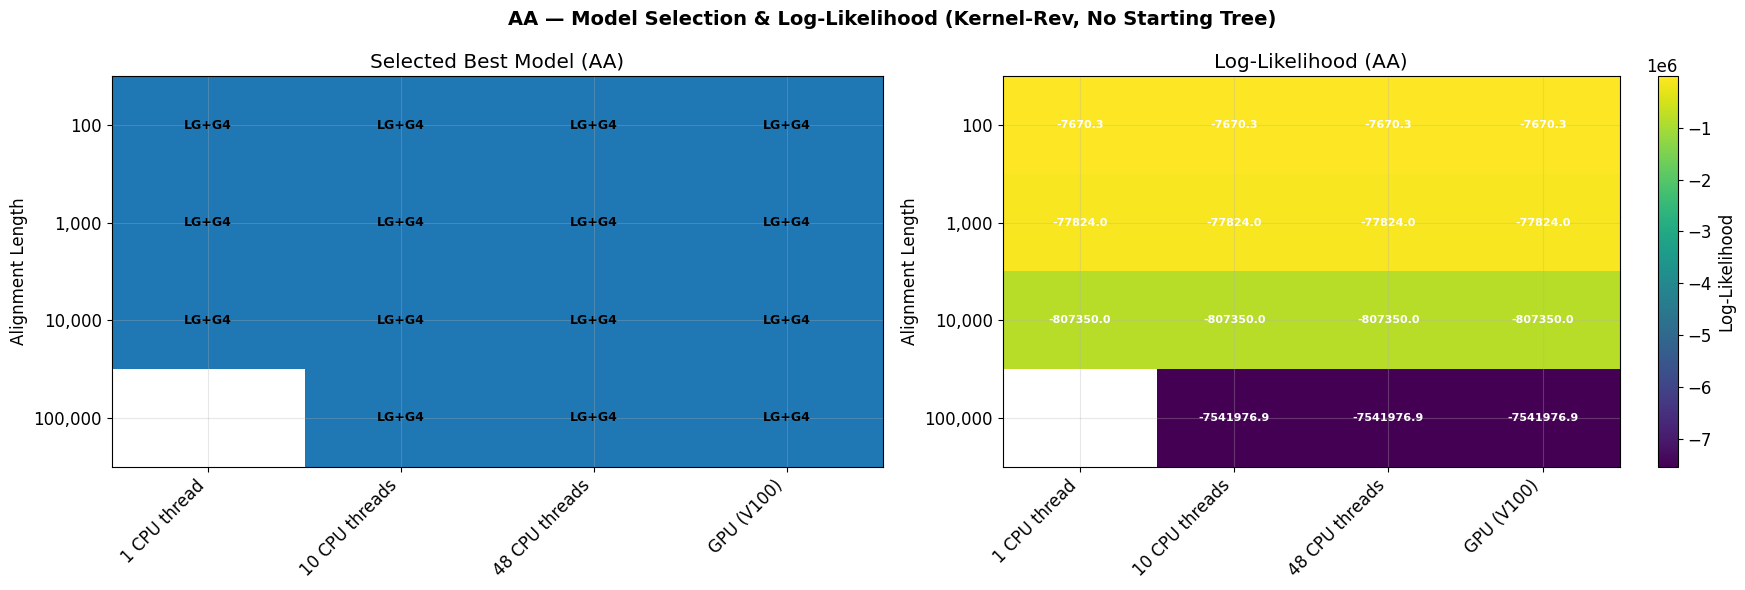

In [15]:
# Model Selection & Log-Likelihood Heatmap (AA)
model_pivot = df.pivot_table(index='length', columns='backend_label', values='best_model', aggfunc='first')
model_pivot = model_pivot[[c for c in backend_order if c in model_pivot.columns]]
all_models_aa = sorted(model_pivot.stack().unique())
model_to_int_aa = {m: i for i, m in enumerate(all_models_aa)}
model_encoded_aa = model_pivot.applymap(lambda x: model_to_int_aa.get(x, -1) if pd.notna(x) else np.nan)

lnl_pivot_aa = df.pivot_table(index='length', columns='backend_label', values='log_likelihood', aggfunc='first')
lnl_pivot_aa = lnl_pivot_aa[[c for c in backend_order if c in lnl_pivot_aa.columns]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

cmap_m = plt.cm.get_cmap('tab10', len(all_models_aa))
im1 = ax1.imshow(model_encoded_aa.values, cmap=cmap_m, aspect='auto', vmin=-0.5, vmax=len(all_models_aa)-0.5)
ax1.set_xticks(range(len(model_encoded_aa.columns)))
ax1.set_xticklabels(model_encoded_aa.columns, rotation=45, ha='right')
ax1.set_yticks(range(len(model_encoded_aa.index)))
ax1.set_yticklabels([f'{l:,}' for l in model_encoded_aa.index])
ax1.set_ylabel('Alignment Length'); ax1.set_title('Selected Best Model (AA)')
for i in range(len(model_encoded_aa.index)):
    for j in range(len(model_encoded_aa.columns)):
        val = model_pivot.iloc[i, j]
        if pd.notna(val):
            ax1.text(j, i, val, ha='center', va='center', fontsize=9, fontweight='bold')

im2 = ax2.imshow(lnl_pivot_aa.values, cmap='viridis', aspect='auto')
ax2.set_xticks(range(len(lnl_pivot_aa.columns)))
ax2.set_xticklabels(lnl_pivot_aa.columns, rotation=45, ha='right')
ax2.set_yticks(range(len(lnl_pivot_aa.index)))
ax2.set_yticklabels([f'{l:,}' for l in lnl_pivot_aa.index])
ax2.set_ylabel('Alignment Length'); ax2.set_title('Log-Likelihood (AA)')
for i in range(len(lnl_pivot_aa.index)):
    for j in range(len(lnl_pivot_aa.columns)):
        val = lnl_pivot_aa.iloc[i, j]
        if pd.notna(val):
            ax2.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
plt.colorbar(im2, ax=ax2, label='Log-Likelihood')

plt.suptitle('AA — Model Selection & Log-Likelihood (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'model_likelihood_heatmap_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Wall-Clock Runtime Comparison (AA)

Wall-Clock Time (seconds) — AA, Kernel-Rev:


backend_label,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,2.6m,3.0m,1.4m,9.5m
1000,20.1m,5.4m,4.4m,8.3m
10000,3.2h,26.2m,11.0m,17.1m
100000,N/A,3.4h,1.3h,1.6h


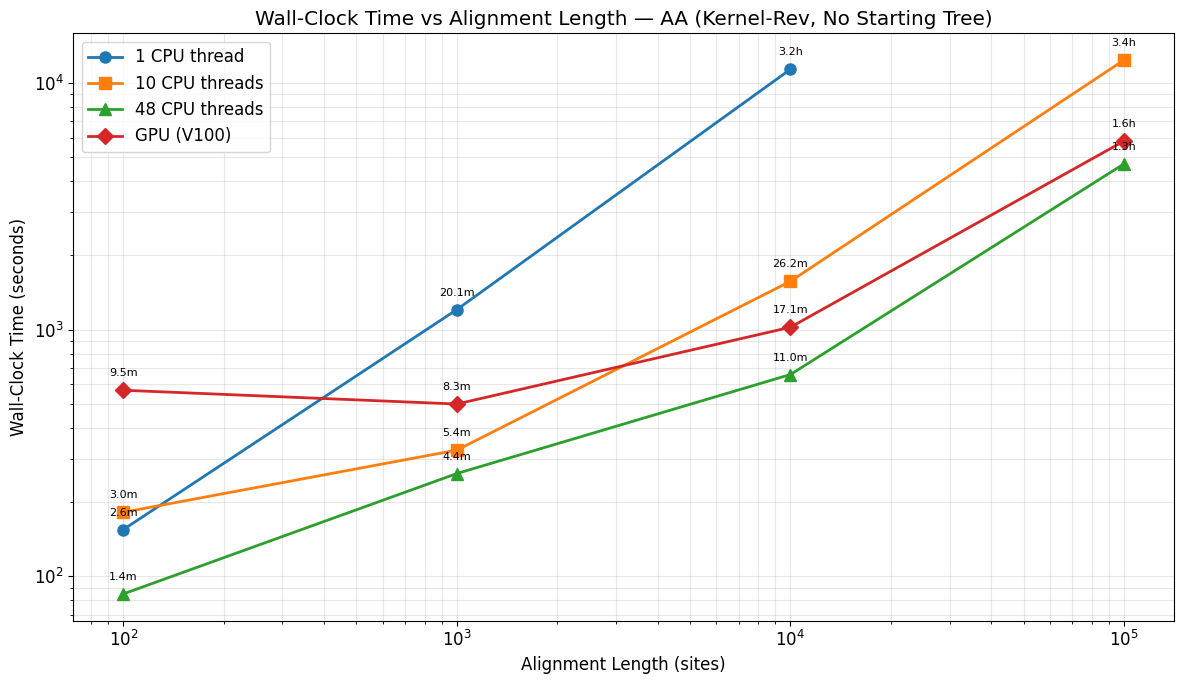

In [16]:
time_pivot_aa = df_aa_rev.pivot_table(index='length', columns='backend_label', values='wall_time_sec', aggfunc='first')
time_pivot_aa = time_pivot_aa[[c for c in backend_order if c in time_pivot_aa.columns]]

print("Wall-Clock Time (seconds) — AA, Kernel-Rev:")
print("=" * 80)
fmt_pivot_aa = time_pivot_aa.copy()
for col in fmt_pivot_aa.columns:
    fmt_pivot_aa[col] = fmt_pivot_aa[col].apply(fmt_time)
display(fmt_pivot_aa)

# Line plot
fig, ax = plt.subplots(figsize=(12, 7))
available_wfs_aa = [c for c in backend_order if c in time_pivot_aa.columns]
for wf in available_wfs_aa:
    data = time_pivot_aa[wf].dropna()
    ax.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
            label=wf, linewidth=2, markersize=8)
    for x, y in zip(data.index, data.values):
        ax.annotate(fmt_time(y), (x, y), textcoords='offset points', xytext=(0, 10),
                    fontsize=8, ha='center')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)'); ax.set_ylabel('Wall-Clock Time (seconds)')
ax.set_title('Wall-Clock Time vs Alignment Length — AA (Kernel-Rev, No Starting Tree)')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

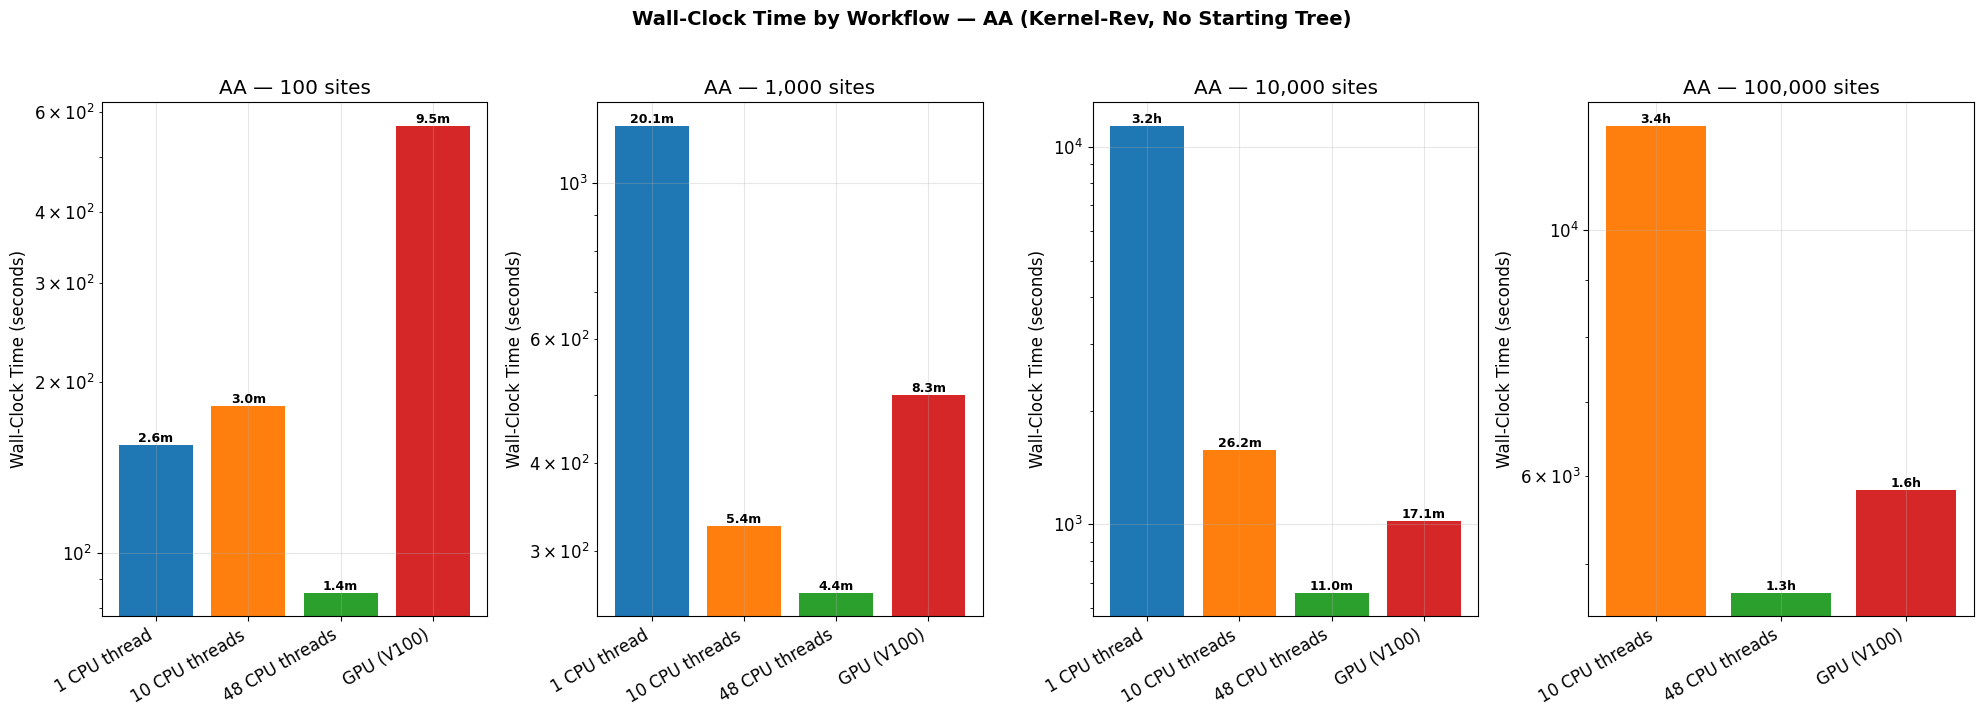

In [17]:
# Bar chart for wall-clock time (AA)
valid_lengths_aa = time_pivot_aa.dropna(thresh=2).index

fig, axes = plt.subplots(1, len(valid_lengths_aa), figsize=(5*len(valid_lengths_aa), 7), sharey=False)
if len(valid_lengths_aa) == 1: axes = [axes]

for ax, length in zip(axes, valid_lengths_aa):
    wfs_present = [c for c in backend_order if c in time_pivot_aa.columns and pd.notna(time_pivot_aa.loc[length, c])]
    times = [time_pivot_aa.loc[length, wf] for wf in wfs_present]
    bar_colors = [wf_colors[wf] for wf in wfs_present]
    bars = ax.bar(range(len(wfs_present)), times, color=bar_colors)
    for bar, t in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt_time(t),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(wfs_present)))
    ax.set_xticklabels(wfs_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'AA — {length:,} sites')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time by Workflow — AA (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Speedup Analysis (AA)

Speedup vs 1 CPU thread (AA, Kernel-Rev):


,1 CPU thread,10 CPU threads,48 CPU threads,GPU (V100)
length,,,,
100,1.0,0.85,1.82,0.27
1000,1.0,3.71,4.62,2.42
10000,1.0,7.24,17.29,11.11
100000,NaN,NaN,NaN,NaN


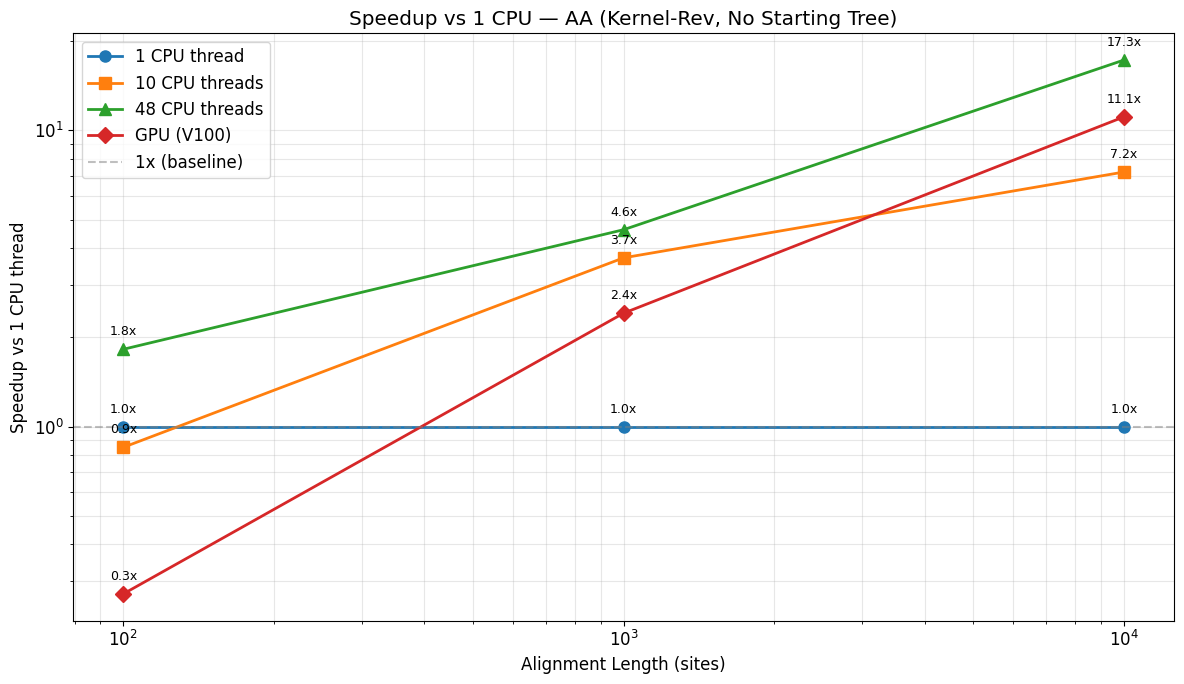

In [18]:
if '1 CPU thread' in time_pivot_aa.columns:
    speedup_df_aa = pd.DataFrame(index=time_pivot_aa.index)
    for wf in available_wfs_aa:
        speedup_df_aa[wf] = time_pivot_aa['1 CPU thread'] / time_pivot_aa[wf]

    print("Speedup vs 1 CPU thread (AA, Kernel-Rev):")
    print("=" * 80)
    display(speedup_df_aa.round(2))

    fig, ax = plt.subplots(figsize=(12, 7))
    for wf in [c for c in backend_order if c in speedup_df_aa.columns]:
        data = speedup_df_aa[wf].dropna()
        ax.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
                label=wf, linewidth=2, markersize=8)
        for x, y in zip(data.index, data.values):
            ax.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 10),
                        fontsize=9, ha='center')

    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='1x (baseline)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)'); ax.set_ylabel('Speedup vs 1 CPU thread')
    ax.set_title('Speedup vs 1 CPU — AA (Kernel-Rev, No Starting Tree)')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Summary: GPU vs CPU (AA)

GPU Speedup Summary — AA (Kernel-Rev, No Starting Tree)


,Sites,GPU,vs 1 CPU thread,vs 10 CPU threads,vs 48 CPU threads
0,100,9.5m,0.27x slower,0.32x slower,0.15x slower
1,"1,000",8.3m,2.42x faster,0.65x slower,0.52x slower
2,"10,000",17.1m,11.11x faster,1.54x faster,0.64x slower
3,"100,000",1.6h,N/A,2.13x faster,0.81x slower


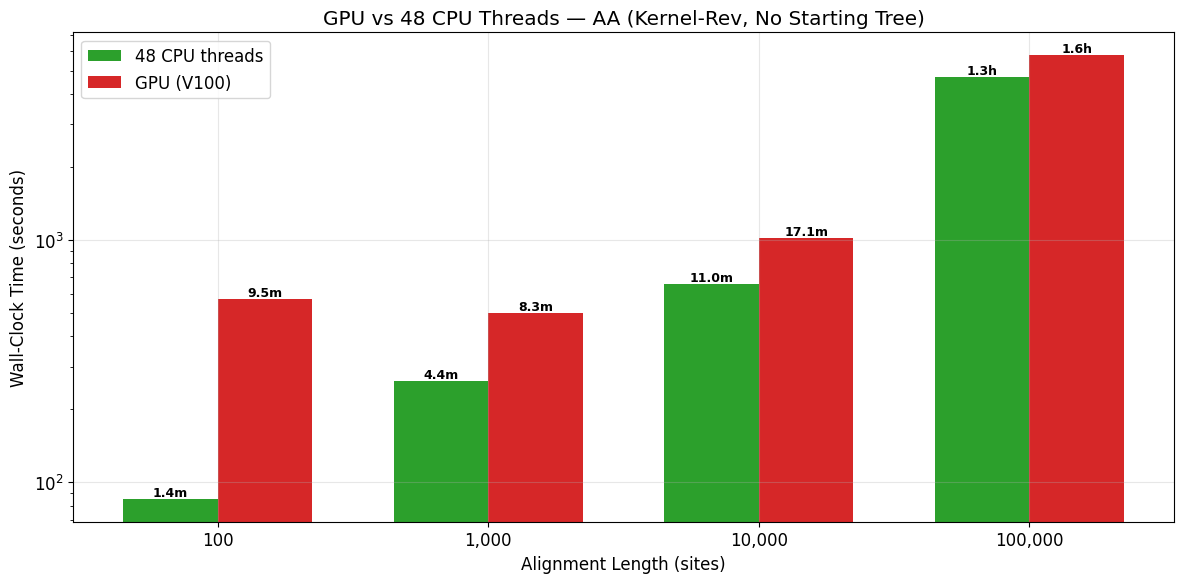

In [19]:
if 'GPU (V100)' in time_pivot_aa.columns:
    summary_rows_aa = []
    for length in time_pivot_aa.index:
        gpu_time = time_pivot_aa.loc[length, 'GPU (V100)']
        row = {'Sites': f'{length:,}', 'GPU': fmt_time(gpu_time)}
        for wf in ['1 CPU thread', '10 CPU threads', '48 CPU threads']:
            if wf in time_pivot_aa.columns:
                cpu_time = time_pivot_aa.loc[length, wf]
                if pd.notna(cpu_time) and pd.notna(gpu_time):
                    ratio = cpu_time / gpu_time
                    row[f'vs {wf}'] = f'{ratio:.2f}x {"faster" if ratio > 1 else "slower"}'
                else:
                    row[f'vs {wf}'] = 'N/A'
        summary_rows_aa.append(row)
    gpu_summary_aa = pd.DataFrame(summary_rows_aa)
    print("GPU Speedup Summary — AA (Kernel-Rev, No Starting Tree)")
    print("=" * 100)
    display(gpu_summary_aa)

# GPU vs 48 CPU bar chart (AA)
if 'GPU (V100)' in time_pivot_aa.columns and '48 CPU threads' in time_pivot_aa.columns:
    common_lengths_aa = time_pivot_aa.dropna(subset=['GPU (V100)', '48 CPU threads']).index
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(common_lengths_aa))
    width = 0.35
    gpu_times = [time_pivot_aa.loc[l, 'GPU (V100)'] for l in common_lengths_aa]
    cpu48_times = [time_pivot_aa.loc[l, '48 CPU threads'] for l in common_lengths_aa]
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPU threads', color=wf_colors['48 CPU threads'])
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=wf_colors['GPU (V100)'])
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l:,}' for l in common_lengths_aa])
    ax.set_xlabel('Alignment Length (sites)'); ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title('GPU vs 48 CPU Threads — AA (Kernel-Rev, No Starting Tree)')
    ax.legend(); ax.set_yscale('log'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 3: Kernel-Rev vs Kernel-NonRev Comparison

Comparing the default kernel (kernel-rev) against kernel-nonrev across all backends and alignment lengths.

## 12. Model Selection Agreement: Rev vs NonRev (DNA)

In [20]:
# Model selection comparison: rev vs nonrev for each backend + length (DNA)
model_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')

print("Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 80)
display(model_comp_dna)

# Check agreement
if 'Kernel-Rev' in model_comp_dna.columns and 'Kernel-NonRev' in model_comp_dna.columns:
    agree = (model_comp_dna['Kernel-Rev'] == model_comp_dna['Kernel-NonRev']).sum()
    total = model_comp_dna.dropna().shape[0]
    print(f"\nAgreement: {agree}/{total} ({agree/total*100:.0f}%)")

Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev    Kernel-Rev
length  backend_label                             
100     1 CPU thread    F81+F+ASC+G4  F81+F+ASC+G4
        10 CPU threads  F81+F+ASC+G4  F81+F+ASC+G4
        48 CPU threads  F81+F+ASC+G4  F81+F+ASC+G4
        GPU (V100)      F81+F+ASC+G4  F81+F+ASC+G4
1000    1 CPU thread        F81+F+G4      F81+F+G4
        10 CPU threads      F81+F+G4      F81+F+G4
        48 CPU threads      F81+F+G4      F81+F+G4
        GPU (V100)          F81+F+G4      F81+F+G4
10000   1 CPU thread        F81+F+G4      F81+F+G4
        10 CPU threads      F81+F+G4      F81+F+G4
        48 CPU threads      F81+F+G4      F81+F+G4
        GPU (V100)          F81+F+G4      F81+F+G4
100000  1 CPU thread        F81+F+G4      F81+F+G4
        10 CPU threads      F81+F+G4      F81+F+G4
        48 CPU threads      F81+F+G4      F81+F+G4
        GPU (V100)          F81+F+G4      F81+F+G4
1000000 10 CPU threads      F81+F+G4      F81+F+G4
        48 CPU threads      F81+F+G4      F81+F+G4
        GPU (V100)          F81+F+G4      F81+F+G4


Agreement: 19/19 (100%)


## 13. Log-Likelihood Comparison: Rev vs NonRev (DNA)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label            Kernel-NonRev    Kernel-Rev  abs_diff
length  backend_label                                        
100     1 CPU thread    -4.896594e+03 -4.894189e+03    2.4047
        10 CPU threads  -4.896594e+03 -4.894189e+03    2.4047
        48 CPU threads  -4.896594e+03 -4.894189e+03    2.4047
        GPU (V100)      -4.894189e+03 -4.894189e+03    0.0000
1000    1 CPU thread    -5.618029e+04 -5.618029e+04    0.0000
        10 CPU threads  -5.618029e+04 -5.618029e+04    0.0000
        48 CPU threads  -5.618029e+04 -5.618029e+04    0.0000
        GPU (V100)      -5.618029e+04 -5.618029e+04    0.0000
10000   1 CPU thread    -5.642088e+05 -5.642088e+05    0.0000
        10 CPU threads  -5.642088e+05 -5.642088e+05    0.0000
        48 CPU threads  -5.642088e+05 -5.642088e+05    0.0000
        GPU (V100)      -5.642088e+05 -5.642088e+05    0.0000
100000  1 CPU thread    -5.692985e+06 -5.692985e+06    0.0000
        10 CPU threads  -5.692985e+06 -5.692985e+06    0.0000
        48 CPU threads  -5.692985e+06 -5.692985e+06    0.0000
        GPU (V100)      -5.692985e+06 -5.692985e+06    0.0000
1000000 10 CPU threads  -5.920802e+07 -5.920802e+07    0.0000
        48 CPU threads  -5.920802e+07 -5.920802e+07    0.0000
        GPU (V100)      -5.920802e+07 -5.920802e+07    0.0000

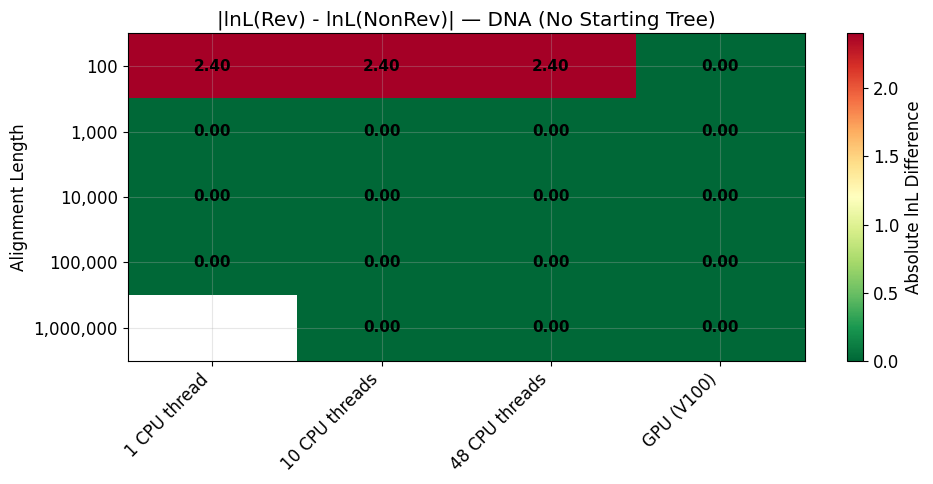

In [21]:
# Log-likelihood comparison: rev vs nonrev (DNA)
lnl_comp_dna_k = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_dna_k.columns and 'Kernel-NonRev' in lnl_comp_dna_k.columns:
    lnl_comp_dna_k['abs_diff'] = (lnl_comp_dna_k['Kernel-Rev'] - lnl_comp_dna_k['Kernel-NonRev']).abs()

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 90)
display(lnl_comp_dna_k.round(4))

# Heatmap
if 'abs_diff' in lnl_comp_dna_k.columns:
    diff_pivot = lnl_comp_dna_k['abs_diff'].unstack(level='backend_label')
    diff_pivot = diff_pivot[[c for c in backend_order if c in diff_pivot.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot.columns)))
    ax.set_xticklabels(diff_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — DNA (No Starting Tree)')

    for i in range(len(diff_pivot.index)):
        for j in range(len(diff_pivot.columns)):
            val = diff_pivot.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 14. Wall-Clock Time: Rev vs NonRev (DNA)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label            Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev
length  backend_label                                                   
100     1 CPU thread           33.904      21.317                  0.629
        10 CPU threads         54.317     109.581                  2.017
        48 CPU threads         94.255     277.338                  2.942
        GPU (V100)            484.641     479.358                  0.989
1000    1 CPU thread          101.005      83.333                  0.825
        10 CPU threads        104.179      47.606                  0.457
        48 CPU threads        246.726     255.769                  1.037
        GPU (V100)            290.351     295.558                  1.018
10000   1 CPU thread         1016.010     898.377                  0.884
        10 CPU threads        329.612     236.633                  0.718
        48 CPU threads        291.816     295.304                  1.012
        GPU (V100)            318.419     335.861                  1.055
100000  1 CPU thread        10938.190    9299.019                  0.850
        10 CPU threads       2816.252    1429.382                  0.508
        48 CPU threads       1226.241     967.302                  0.789
        GPU (V100)            988.491     986.038                  0.998
1000000 10 CPU threads      36615.381   29249.834                  0.799
        48 CPU threads      18850.714   16874.497                  0.895
        GPU (V100)           9569.167    9548.197                  0.998

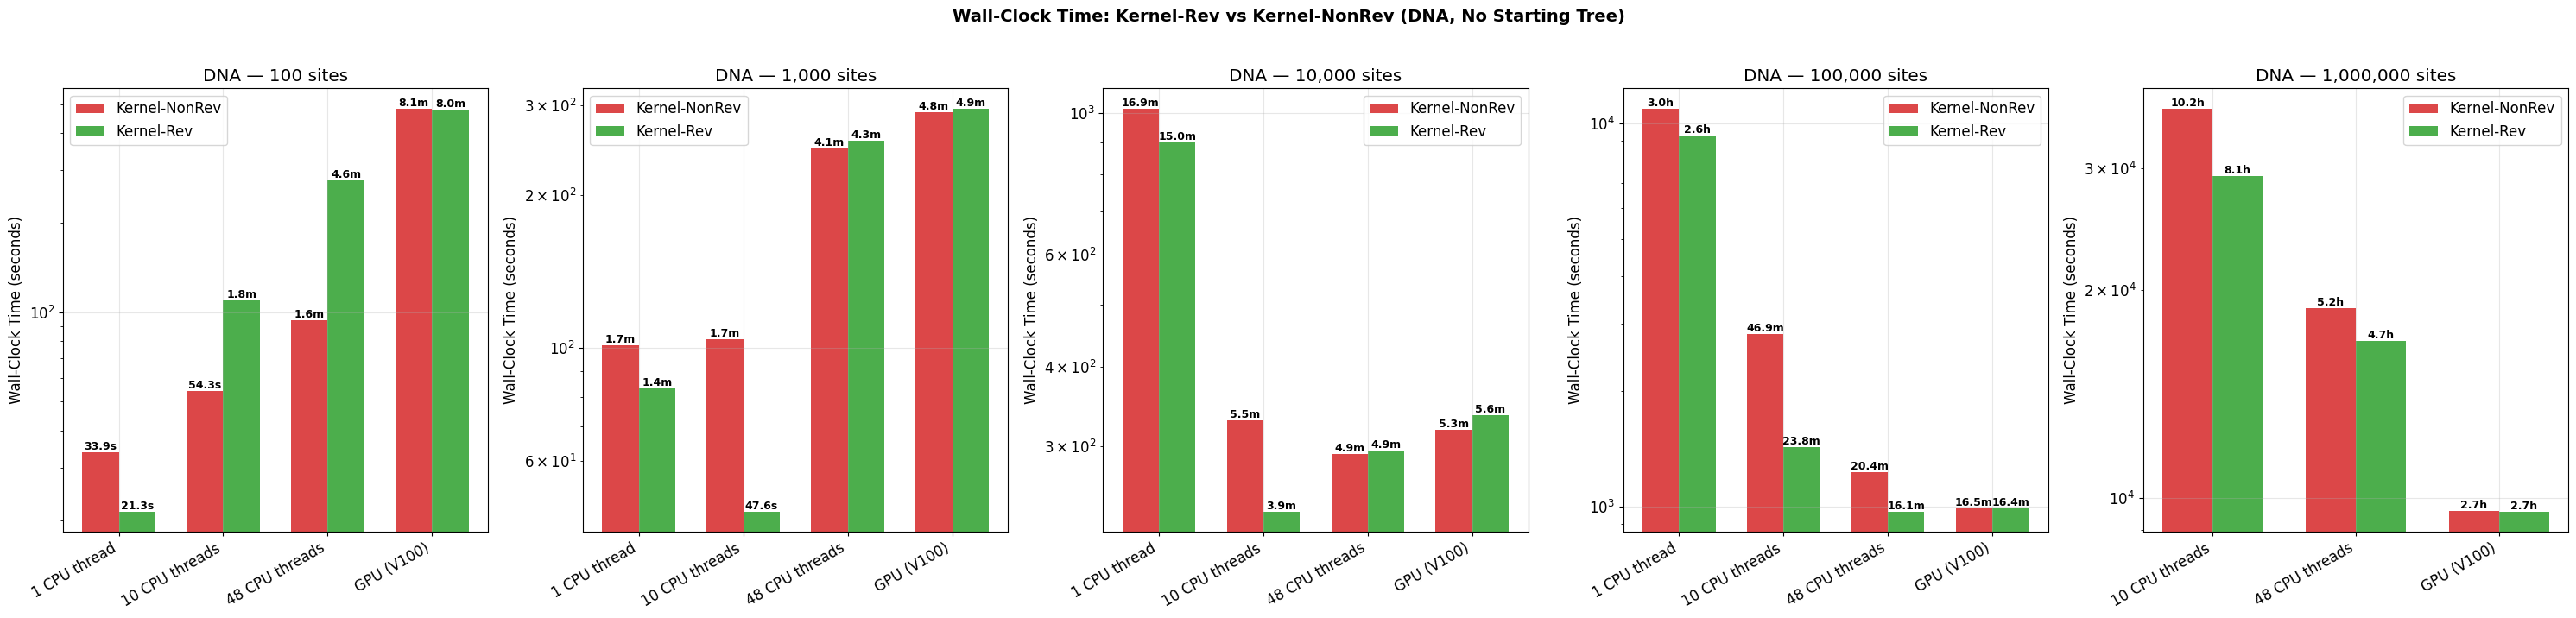

In [22]:
# Wall-clock time pivot table (DNA) — kernel comparison
time_comp_dna_k = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_dna_k.columns and 'Kernel-NonRev' in time_comp_dna_k.columns:
    time_comp_dna_k['ratio_rev_over_nonrev'] = time_comp_dna_k['Kernel-Rev'] / time_comp_dna_k['Kernel-NonRev']

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
display(time_comp_dna_k.round(3))

# Grouped bar chart: wall-clock time rev vs nonrev per backend, one subplot per alignment length
dna_lengths_k = sorted(df_dna['length'].unique())
n_lengths = len(dna_lengths_k)

fig, axes = plt.subplots(1, n_lengths, figsize=(6 * n_lengths, 7), sharey=False)
if n_lengths == 1: axes = [axes]

for ax, length in zip(axes, dna_lengths_k):
    sub = df_dna[df_dna['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'DNA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA, No Starting Tree)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dna_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Speedup Ratio: NonRev/Rev (DNA)

Ratio = NonRev_time / Rev_time. Values > 1 mean kernel-rev is faster; < 1 means kernel-nonrev is faster.

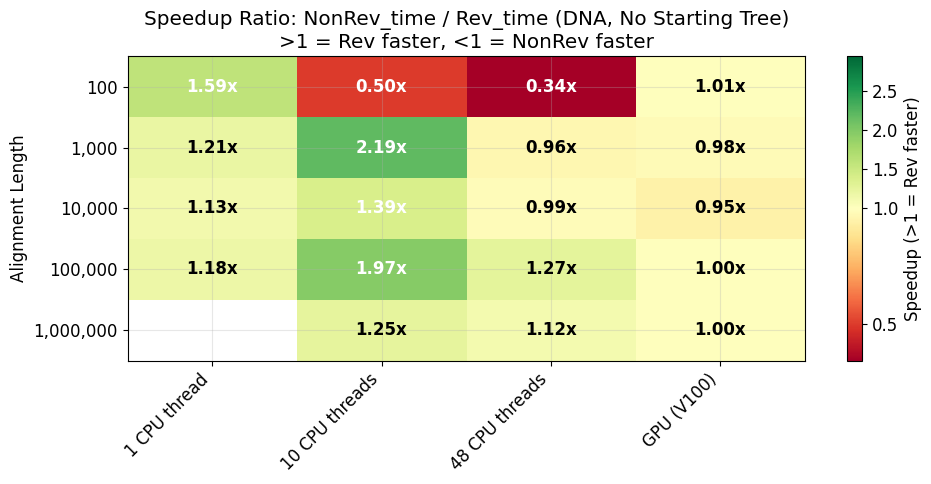

In [23]:
# Speedup heatmap: NonRev_time / Rev_time (DNA)
if 'Kernel-Rev' in time_comp_dna_k.columns and 'Kernel-NonRev' in time_comp_dna_k.columns:
    speedup = (time_comp_dna_k['Kernel-NonRev'] / time_comp_dna_k['Kernel-Rev']).unstack(level='backend_label')
    speedup = speedup[[c for c in backend_order if c in speedup.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    vmin = min(speedup.min().min(), 1/speedup.max().max())
    vmax = max(speedup.max().max(), 1/speedup.min().min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup.columns)))
    ax.set_xticklabels(speedup.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (DNA, No Starting Tree)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup.index)):
        for j in range(len(speedup.columns)):
            val = speedup.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 16. Model Selection Agreement: Rev vs NonRev (AA)

In [24]:
# Model selection comparison (AA)
model_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')

print("Model Selection: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 80)
display(model_comp_aa)

if 'Kernel-Rev' in model_comp_aa.columns and 'Kernel-NonRev' in model_comp_aa.columns:
    agree = (model_comp_aa['Kernel-Rev'] == model_comp_aa['Kernel-NonRev']).sum()
    total = model_comp_aa.dropna().shape[0]
    print(f"\nAgreement: {agree}/{total} ({agree/total*100:.0f}%)")

Model Selection: Kernel-Rev vs Kernel-NonRev (AA)


kernel_label          Kernel-NonRev Kernel-Rev
length backend_label                          
100    1 CPU thread           LG+G4      LG+G4
       10 CPU threads         LG+G4      LG+G4
       48 CPU threads         LG+G4      LG+G4
       GPU (V100)             LG+G4      LG+G4
1000   1 CPU thread           LG+G4      LG+G4
       10 CPU threads         LG+G4      LG+G4
       48 CPU threads         LG+G4      LG+G4
       GPU (V100)             LG+G4      LG+G4
10000  1 CPU thread           LG+G4      LG+G4
       10 CPU threads         LG+G4      LG+G4
       48 CPU threads         LG+G4      LG+G4
       GPU (V100)             LG+G4      LG+G4
100000 10 CPU threads         LG+G4      LG+G4
       48 CPU threads         LG+G4      LG+G4
       GPU (V100)             LG+G4      LG+G4


Agreement: 15/15 (100%)


## 17. Log-Likelihood Comparison: Rev vs NonRev (AA)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff
length backend_label                                        
100    1 CPU thread    -7.670271e+03 -7.670271e+03    0.0000
       10 CPU threads  -7.670271e+03 -7.670271e+03    0.0000
       48 CPU threads  -7.670271e+03 -7.670271e+03    0.0000
       GPU (V100)      -7.670271e+03 -7.670271e+03    0.0000
1000   1 CPU thread    -7.782396e+04 -7.782396e+04    0.0000
       10 CPU threads  -7.782396e+04 -7.782396e+04    0.0000
       48 CPU threads  -7.782396e+04 -7.782396e+04    0.0000
       GPU (V100)      -7.782396e+04 -7.782396e+04    0.0000
10000  1 CPU thread    -8.073500e+05 -8.073500e+05    0.0000
       10 CPU threads  -8.073500e+05 -8.073500e+05    0.0000
       48 CPU threads  -8.073500e+05 -8.073500e+05    0.0000
       GPU (V100)      -8.073500e+05 -8.073500e+05    0.0000
100000 10 CPU threads  -7.541977e+06 -7.541977e+06    0.0028
       48 CPU threads  -7.541977e+06 -7.541977e+06    0.0001
       GPU (V100)      -7.541977e+06 -7.541977e+06    0.0000

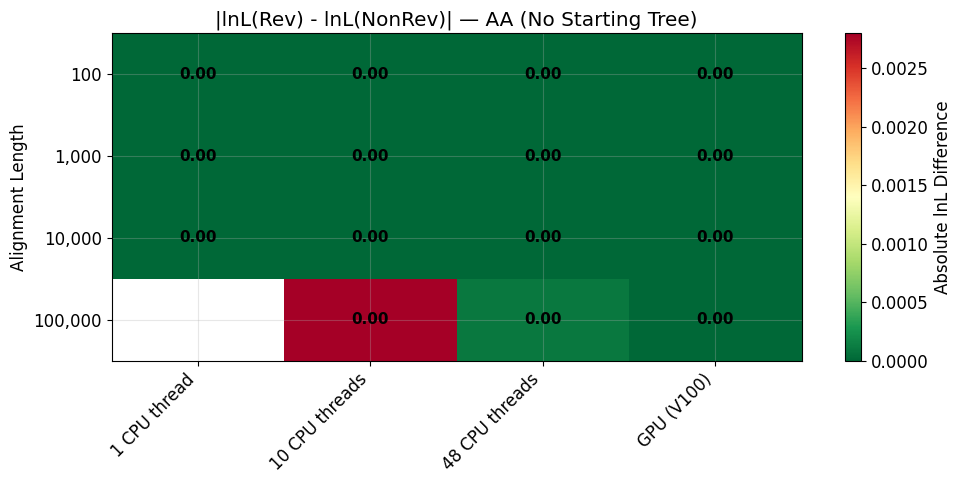

In [25]:
# Log-likelihood comparison (AA)
lnl_comp_aa_k = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_aa_k.columns and 'Kernel-NonRev' in lnl_comp_aa_k.columns:
    lnl_comp_aa_k['abs_diff'] = (lnl_comp_aa_k['Kernel-Rev'] - lnl_comp_aa_k['Kernel-NonRev']).abs()

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 90)
display(lnl_comp_aa_k.round(4))

# Heatmap
if 'abs_diff' in lnl_comp_aa_k.columns:
    diff_pivot_aa = lnl_comp_aa_k['abs_diff'].unstack(level='backend_label')
    diff_pivot_aa = diff_pivot_aa[[c for c in backend_order if c in diff_pivot_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_aa.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot_aa.columns)))
    ax.set_xticklabels(diff_pivot_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — AA (No Starting Tree)')

    for i in range(len(diff_pivot_aa.index)):
        for j in range(len(diff_pivot_aa.columns)):
            val = diff_pivot_aa.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 18. Wall-Clock Time & Speedup Heatmap: Rev vs NonRev (AA)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev
length backend_label                                                   
100    1 CPU thread          679.974     154.804                  0.228
       10 CPU threads        462.204     181.870                  0.393
       48 CPU threads        465.576      84.866                  0.182
       GPU (V100)            552.612     568.400                  1.029
1000   1 CPU thread         2576.620    1207.190                  0.469
       10 CPU threads        632.140     325.009                  0.514
       48 CPU threads        582.933     261.189                  0.448
       GPU (V100)            501.791     499.779                  0.996
10000  1 CPU thread        21609.600   11376.100                  0.526
       10 CPU threads       2605.340    1571.800                  0.603
       48 CPU threads       1169.630     658.143                  0.563
       GPU (V100)           1017.240    1023.540                  1.006
100000 10 CPU threads      22682.080   12406.600                  0.547
       48 CPU threads       6484.726    4704.717                  0.726
       GPU (V100)           5834.194    5824.160                  0.998

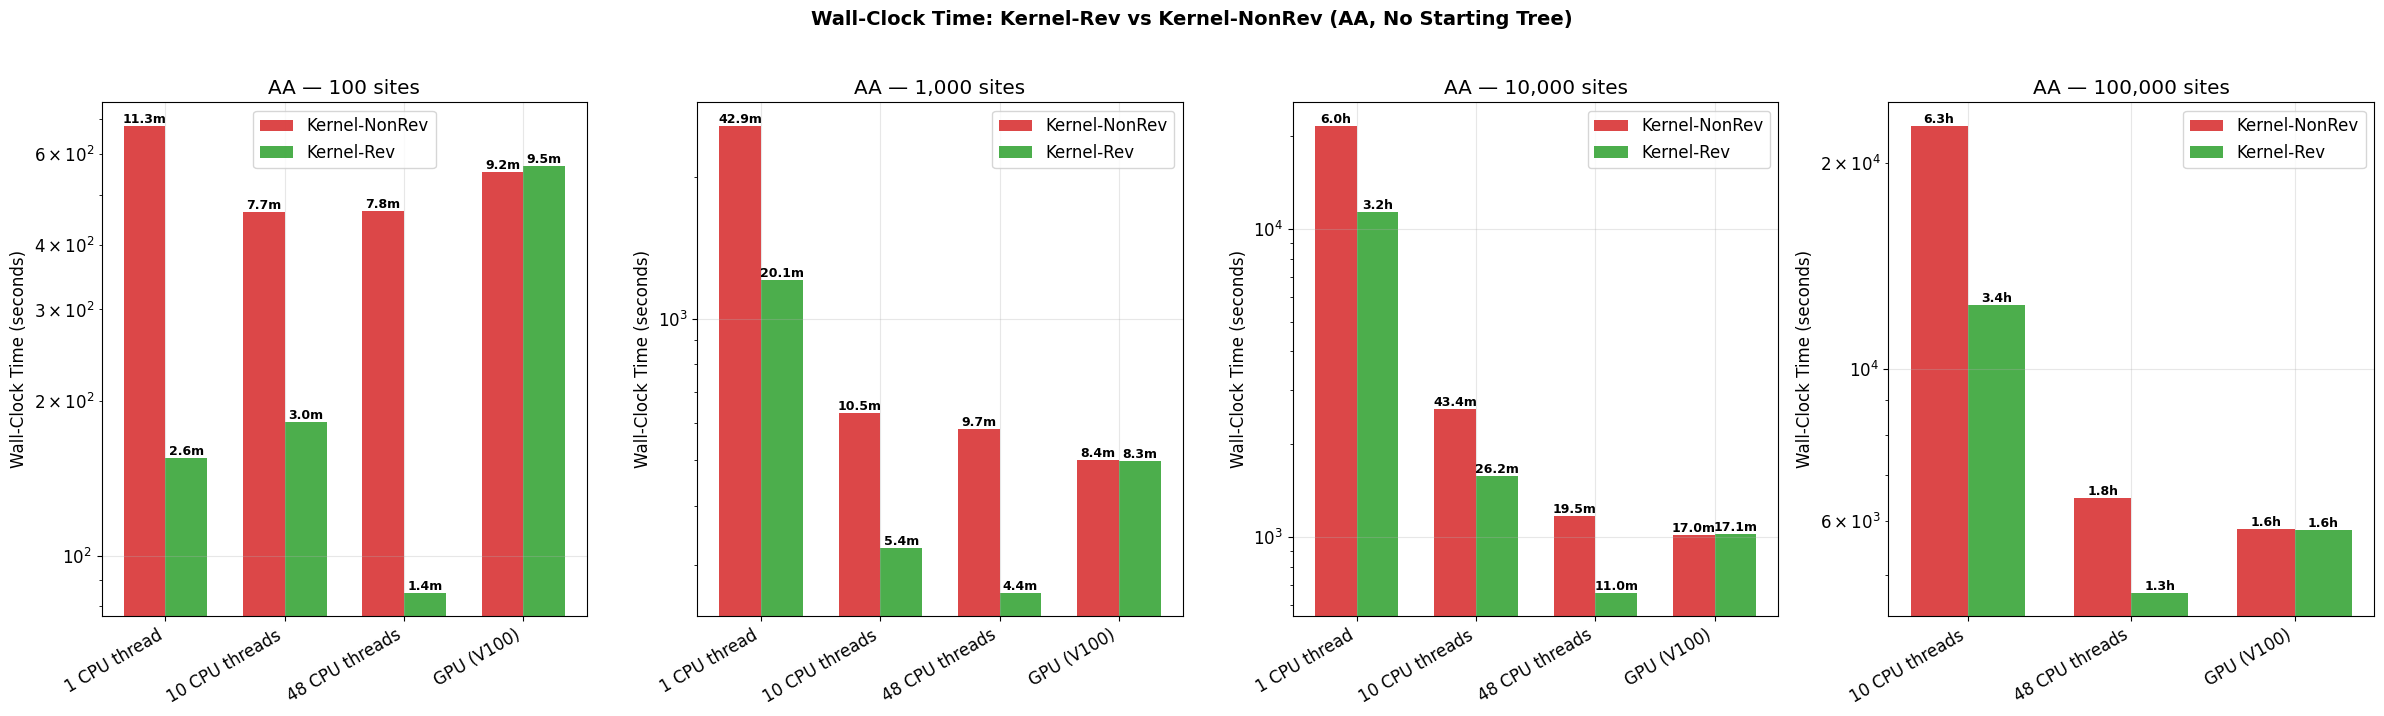

In [26]:
# Wall-clock time pivot table (AA)
time_comp_aa_k = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_aa_k.columns and 'Kernel-NonRev' in time_comp_aa_k.columns:
    time_comp_aa_k['ratio_rev_over_nonrev'] = time_comp_aa_k['Kernel-Rev'] / time_comp_aa_k['Kernel-NonRev']

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
display(time_comp_aa_k.round(3))

# Grouped bar chart (AA)
aa_lengths_k = sorted(df_aa['length'].unique())
n_lengths = len(aa_lengths_k)

fig, axes = plt.subplots(1, n_lengths, figsize=(6 * n_lengths, 7), sharey=False)
if n_lengths == 1: axes = [axes]

for ax, length in zip(axes, aa_lengths_k):
    sub = df_aa[df_aa['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'AA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA, No Starting Tree)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'aa_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

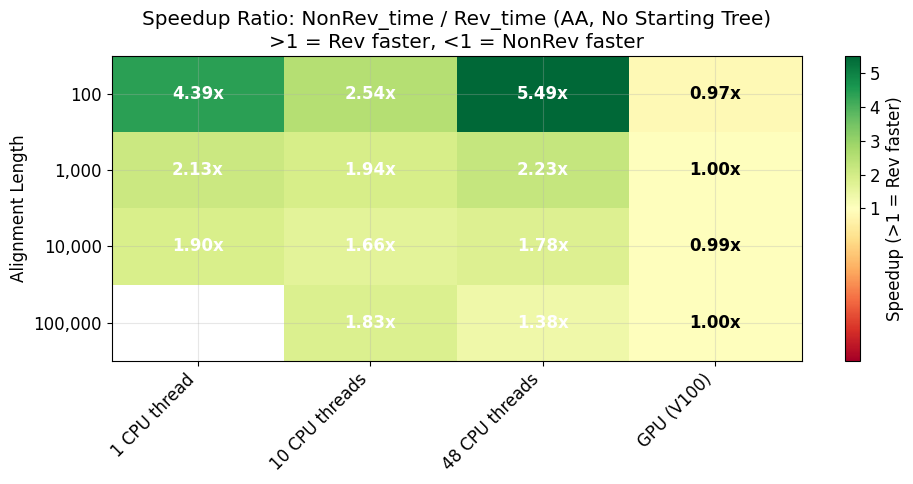

In [27]:
# Speedup heatmap (AA)
if 'Kernel-Rev' in time_comp_aa_k.columns and 'Kernel-NonRev' in time_comp_aa_k.columns:
    speedup_aa = (time_comp_aa_k['Kernel-NonRev'] / time_comp_aa_k['Kernel-Rev']).unstack(level='backend_label')
    speedup_aa = speedup_aa[[c for c in backend_order if c in speedup_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    vmin = min(speedup_aa.min().min(), 1/speedup_aa.max().max())
    vmax = max(speedup_aa.max().max(), 1/speedup_aa.min().min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup_aa.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup_aa.columns)))
    ax.set_xticklabels(speedup_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (AA, No Starting Tree)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup_aa.index)):
        for j in range(len(speedup_aa.columns)):
            val = speedup_aa.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 4: Combined DNA + AA Comparison

## 19. Side-by-Side Wall-Clock Time (DNA vs AA)

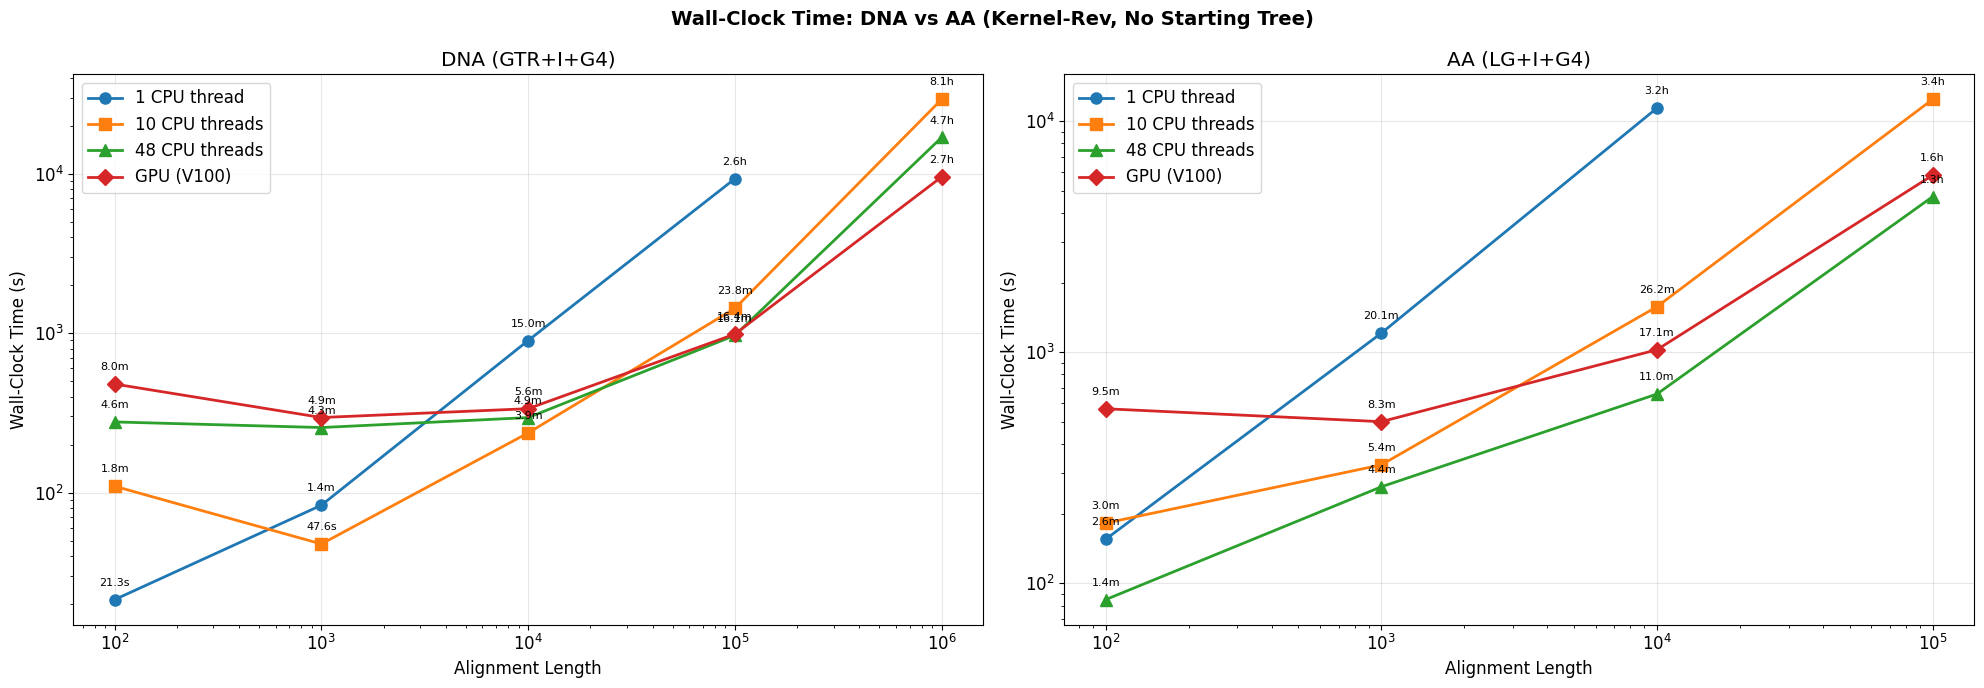

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# DNA
for wf in [c for c in backend_order if c in time_pivot_dna.columns]:
    data = time_pivot_dna[wf].dropna()
    ax1.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
             label=wf, linewidth=2, markersize=8)
    for x, y in zip(data.index, data.values):
        ax1.annotate(fmt_time(y), (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length'); ax1.set_ylabel('Wall-Clock Time (s)')
ax1.set_title('DNA (GTR+I+G4)'); ax1.legend(); ax1.grid(True, alpha=0.3)

# AA
for wf in [c for c in backend_order if c in time_pivot_aa.columns]:
    data = time_pivot_aa[wf].dropna()
    ax2.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
             label=wf, linewidth=2, markersize=8)
    for x, y in zip(data.index, data.values):
        ax2.annotate(fmt_time(y), (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length'); ax2.set_ylabel('Wall-Clock Time (s)')
ax2.set_title('AA (LG+I+G4)'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Wall-Clock Time: DNA vs AA (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_dna_vs_aa.png'), dpi=150, bbox_inches='tight')
plt.show()

## 20. Side-by-Side Speedup (DNA vs AA)

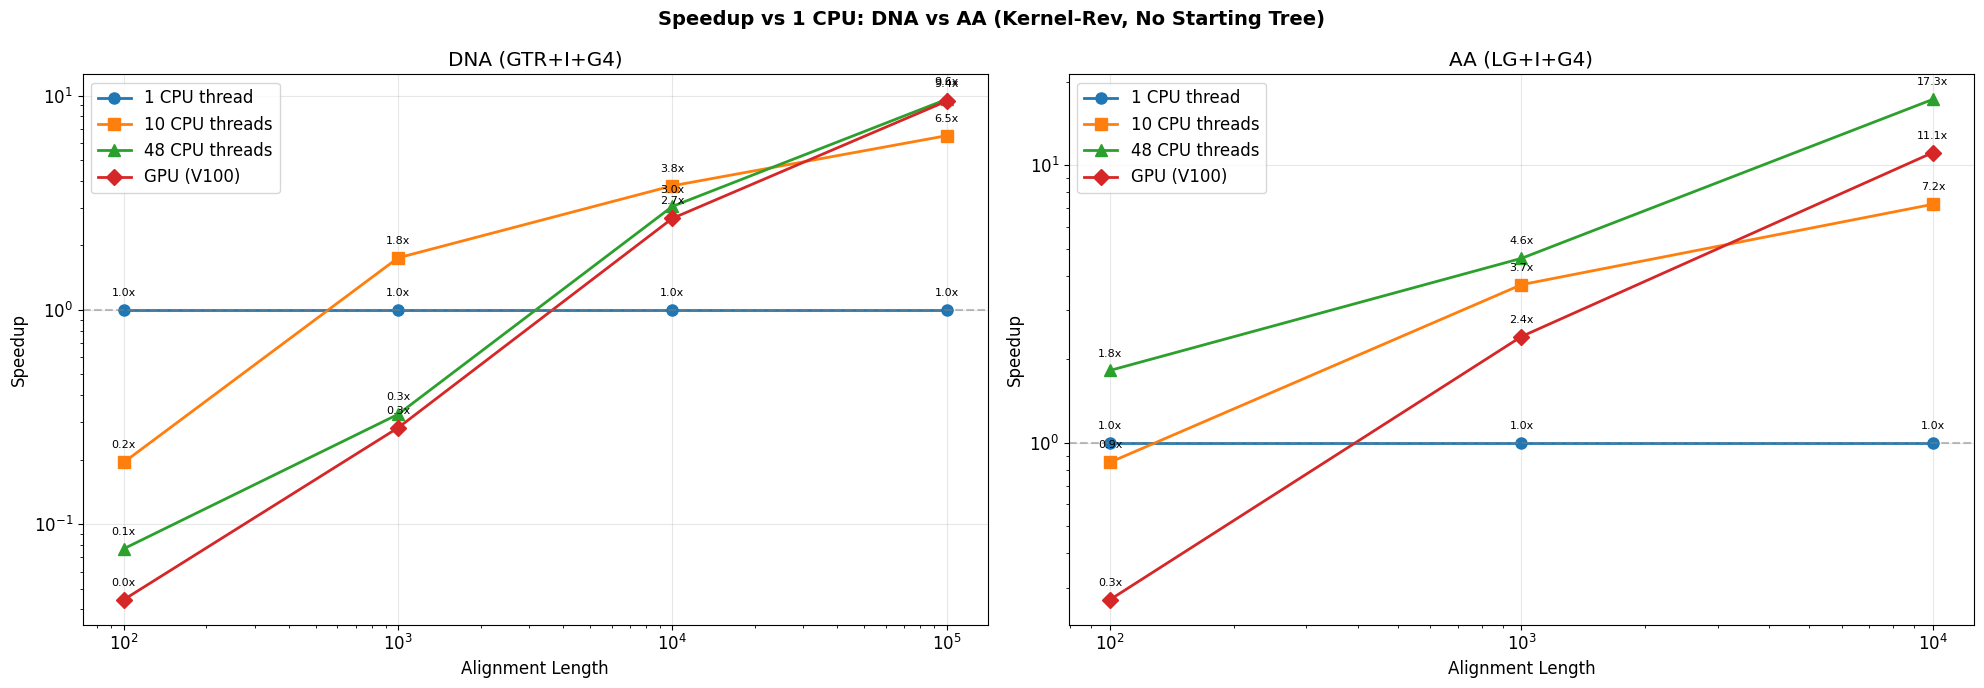

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# DNA speedup
if '1 CPU thread' in time_pivot_dna.columns:
    for wf in [c for c in backend_order if c in speedup_df_dna.columns]:
        data = speedup_df_dna[wf].dropna()
        ax1.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
                 label=wf, linewidth=2, markersize=8)
        for x, y in zip(data.index, data.values):
            ax1.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length'); ax1.set_ylabel('Speedup')
ax1.set_title('DNA (GTR+I+G4)'); ax1.legend(); ax1.grid(True, alpha=0.3)

# AA speedup
if '1 CPU thread' in time_pivot_aa.columns:
    for wf in [c for c in backend_order if c in speedup_df_aa.columns]:
        data = speedup_df_aa[wf].dropna()
        ax2.plot(data.index, data.values, marker=wf_markers[wf], color=wf_colors[wf],
                 label=wf, linewidth=2, markersize=8)
        for x, y in zip(data.index, data.values):
            ax2.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length'); ax2.set_ylabel('Speedup')
ax2.set_title('AA (LG+I+G4)'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Speedup vs 1 CPU: DNA vs AA (Kernel-Rev, No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'speedup_dna_vs_aa.png'), dpi=150, bbox_inches='tight')
plt.show()

## 21. Combined Kernel Speedup Heatmap (DNA + AA)

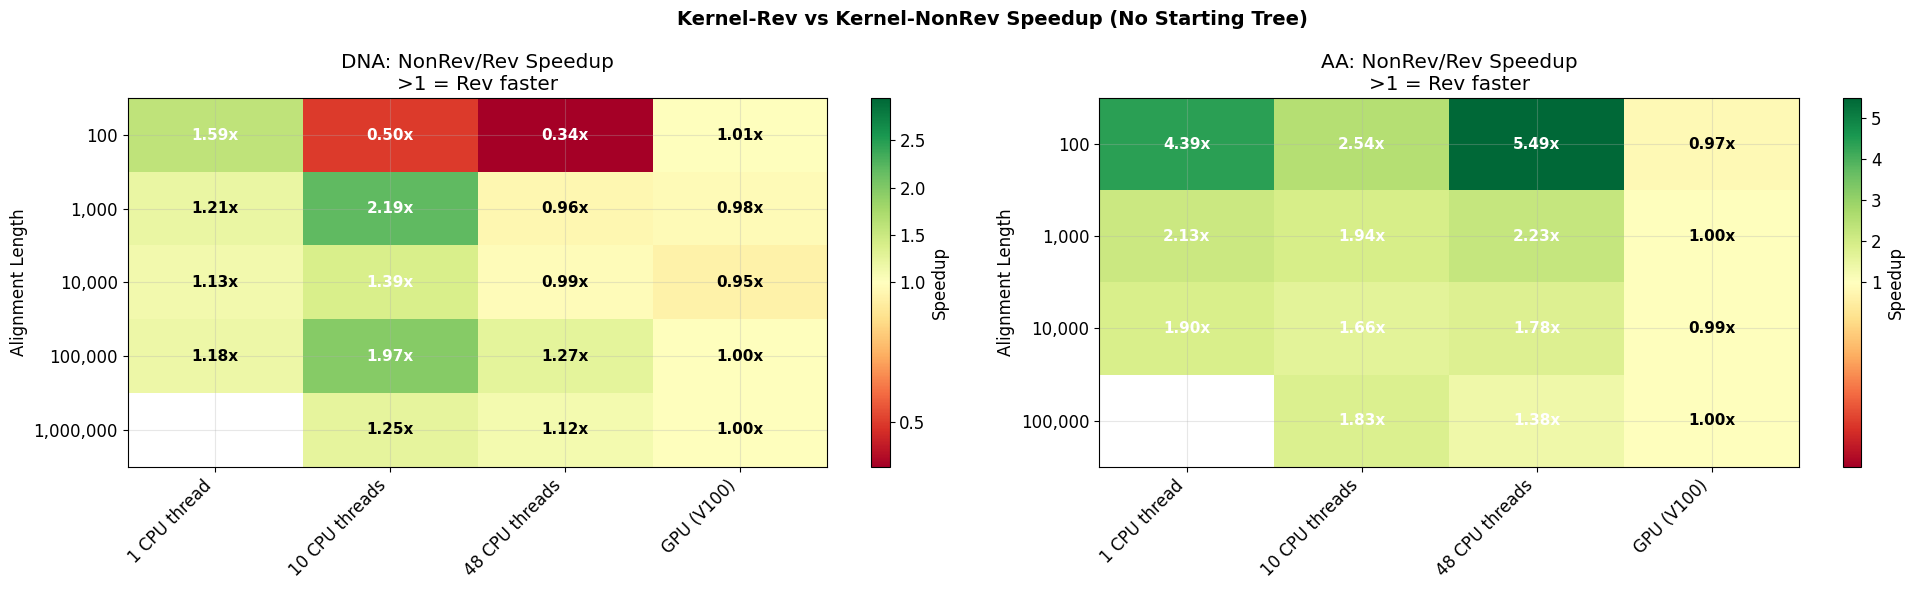

In [30]:
# Combined speedup heatmap: both DNA and AA kernel comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

for ax, dtype_label, time_comp in [(ax1, 'DNA', time_comp_dna_k), (ax2, 'AA', time_comp_aa_k)]:
    if 'Kernel-Rev' not in time_comp.columns or 'Kernel-NonRev' not in time_comp.columns:
        continue
    speedup_k = (time_comp['Kernel-NonRev'] / time_comp['Kernel-Rev']).unstack(level='backend_label')
    speedup_k = speedup_k[[c for c in backend_order if c in speedup_k.columns]]

    all_vals = speedup_k.values[~np.isnan(speedup_k.values)]
    if len(all_vals) == 0: continue
    vmin = min(all_vals.min(), 1/all_vals.max())
    vmax = max(all_vals.max(), 1/all_vals.min())
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup_k.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup_k.columns)))
    ax.set_xticklabels(speedup_k.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_k.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_k.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title(f'{dtype_label}: NonRev/Rev Speedup\n>1 = Rev faster')

    for i in range(len(speedup_k.index)):
        for j in range(len(speedup_k.columns)):
            val = speedup_k.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=11, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup')

plt.suptitle('Kernel-Rev vs Kernel-NonRev Speedup (No Starting Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'combined_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 22. Combined Summary Table

In [31]:
# Combined summary: all data types, all lengths
df_all = pd.concat([df_dna, df_aa], ignore_index=True)

print('=' * 130)
print('COMBINED SUMMARY: All Data Types, All Lengths, All Workflows, All Kernels')
print('=' * 130)

for dtype in ['DNA', 'AA']:
    sub = df_all[df_all['data_type'] == dtype]
    print(f'\n--- {dtype} ---')
    pivot = sub.pivot_table(
        index=['length', 'kernel_label'],
        columns='backend_label',
        values='wall_time_sec',
        aggfunc='first'
    )
    pivot = pivot[[c for c in backend_order if c in pivot.columns]]
    fmt = pivot.applymap(fmt_time)
    display(fmt)

COMBINED SUMMARY: All Data Types, All Lengths, All Workflows, All Kernels

--- DNA ---


backend_label         1 CPU thread 10 CPU threads 48 CPU threads GPU (V100)
length  kernel_label                                                       
100     Kernel-NonRev        33.9s          54.3s           1.6m       8.1m
        Kernel-Rev           21.3s           1.8m           4.6m       8.0m
1000    Kernel-NonRev         1.7m           1.7m           4.1m       4.8m
        Kernel-Rev            1.4m          47.6s           4.3m       4.9m
10000   Kernel-NonRev        16.9m           5.5m           4.9m       5.3m
        Kernel-Rev           15.0m           3.9m           4.9m       5.6m
100000  Kernel-NonRev         3.0h          46.9m          20.4m      16.5m
        Kernel-Rev            2.6h          23.8m          16.1m      16.4m
1000000 Kernel-NonRev          N/A          10.2h           5.2h       2.7h
        Kernel-Rev             N/A           8.1h           4.7h       2.7h


--- AA ---


backend_label        1 CPU thread 10 CPU threads 48 CPU threads GPU (V100)
length kernel_label                                                       
100    Kernel-NonRev        11.3m           7.7m           7.8m       9.2m
       Kernel-Rev            2.6m           3.0m           1.4m       9.5m
1000   Kernel-NonRev        42.9m          10.5m           9.7m       8.4m
       Kernel-Rev           20.1m           5.4m           4.4m       8.3m
10000  Kernel-NonRev         6.0h          43.4m          19.5m      17.0m
       Kernel-Rev            3.2h          26.2m          11.0m      17.1m
100000 Kernel-NonRev          N/A           6.3h           1.8h       1.6h
       Kernel-Rev             N/A           3.4h           1.3h       1.6h

## 23. Data Completeness Report

In [32]:
# Show which runs are complete vs missing
print('Data Completeness (from .iqtree files):')
print()

all_lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
all_backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
all_kernels = ['default', 'kernelnonrev']

for dtype in ['DNA', 'AA']:
    print(f'=== {dtype} ===')
    for length in all_lengths:
        present = []
        missing = []
        for kernel in all_kernels:
            for backend in all_backends:
                label = f'{kernel_labels[kernel]}_{backend_labels[backend]}'
                match = df_all[(df_all['data_type'] == dtype) & (df_all['length'] == length) &
                          (df_all['kernel'] == kernel) & (df_all['backend'] == backend)]
                if len(match) > 0:
                    present.append(label)
                else:
                    missing.append(label)
        total = len(present) + len(missing)
        print(f'  len_{length:>10,}: {len(present)}/{total} present', end='')
        if missing:
            print(f'  MISSING: {", ".join(missing)}')
        else:
            print('  (complete)')
    print()

Data Completeness (from .iqtree files):

=== DNA ===
  len_       100: 8/8 present  (complete)
  len_     1,000: 8/8 present  (complete)
  len_    10,000: 8/8 present  (complete)
  len_   100,000: 8/8 present  (complete)
  len_ 1,000,000: 6/8 present  MISSING: Kernel-Rev_1 CPU thread, Kernel-NonRev_1 CPU thread
  len_10,000,000: 0/8 present  MISSING: Kernel-Rev_1 CPU thread, Kernel-Rev_10 CPU threads, Kernel-Rev_48 CPU threads, Kernel-Rev_GPU (V100), Kernel-NonRev_1 CPU thread, Kernel-NonRev_10 CPU threads, Kernel-NonRev_48 CPU threads, Kernel-NonRev_GPU (V100)

=== AA ===
  len_       100: 8/8 present  (complete)
  len_     1,000: 8/8 present  (complete)
  len_    10,000: 8/8 present  (complete)
  len_   100,000: 6/8 present  MISSING: Kernel-Rev_1 CPU thread, Kernel-NonRev_1 CPU thread
  len_ 1,000,000: 0/8 present  MISSING: Kernel-Rev_1 CPU thread, Kernel-Rev_10 CPU threads, Kernel-Rev_48 CPU threads, Kernel-Rev_GPU (V100), Kernel-NonRev_1 CPU thread, Kernel-NonRev_10 CPU threads, Ke

## 24. Gamma Shape Alpha Comparison

In [33]:
if 'gamma_alpha' in df_all.columns:
    for dtype in ['DNA', 'AA']:
        sub = df_all[df_all['data_type'] == dtype]
        if 'gamma_alpha' not in sub.columns or sub['gamma_alpha'].isna().all():
            continue
        gamma_pivot = sub.pivot_table(
            index=['length', 'kernel_label'],
            columns='backend_label',
            values='gamma_alpha',
            aggfunc='first'
        )
        gamma_pivot = gamma_pivot[[c for c in backend_order if c in gamma_pivot.columns]]
        print(f'\nGamma Shape Alpha — {dtype}:')
        display(gamma_pivot.round(6))

        # Check max difference
        for length in gamma_pivot.index.get_level_values(0).unique():
            vals = gamma_pivot.loc[length].values.flatten()
            vals = vals[~np.isnan(vals)]
            if len(vals) > 1:
                max_diff = vals.max() - vals.min()
                print(f'  Length {length:>10,}: max diff = {max_diff:.6f}')


Gamma Shape Alpha — DNA:


backend_label          1 CPU thread  10 CPU threads  48 CPU threads  \
length  kernel_label                                                  
100     Kernel-NonRev        0.8438          0.8438          0.8438   
        Kernel-Rev           0.8014          0.8014          0.8014   
1000    Kernel-NonRev        1.0080          1.0080          1.0080   
        Kernel-Rev           1.0080          1.0080          1.0080   
10000   Kernel-NonRev        0.9844          0.9844          0.9844   
        Kernel-Rev           0.9844          0.9844          0.9844   
100000  Kernel-NonRev        1.0090          1.0090          1.0090   
        Kernel-Rev           1.0090          1.0090          1.0090   
1000000 Kernel-NonRev           NaN          0.9996          0.9996   
        Kernel-Rev              NaN          0.9996          0.9996   

backend_label          GPU (V100)  
length  kernel_label               
100     Kernel-NonRev      0.8013  
        Kernel-Rev         0.8013  
1000    Kernel-NonRev      1.0080  
        Kernel-Rev         1.0080  
10000   Kernel-NonRev      0.9844  
        Kernel-Rev         0.9844  
100000  Kernel-NonRev      1.0090  
        Kernel-Rev         1.0090  
1000000 Kernel-NonRev      0.9996  
        Kernel-Rev         0.9996

  Length        100: max diff = 0.042500
  Length      1,000: max diff = 0.000000
  Length     10,000: max diff = 0.000000
  Length    100,000: max diff = 0.000000
  Length  1,000,000: max diff = 0.000000

Gamma Shape Alpha — AA:


backend_label         1 CPU thread  10 CPU threads  48 CPU threads  GPU (V100)
length kernel_label                                                           
100    Kernel-NonRev        0.9851          0.9851          0.9851      0.9851
       Kernel-Rev           0.9851          0.9851          0.9851      0.9851
1000   Kernel-NonRev        1.0081          1.0081          1.0081      1.0081
       Kernel-Rev           1.0081          1.0081          1.0081      1.0081
10000  Kernel-NonRev        1.0047          1.0047          1.0047      1.0047
       Kernel-Rev           1.0047          1.0047          1.0047      1.0047
100000 Kernel-NonRev           NaN          0.9966          0.9966      0.9966
       Kernel-Rev              NaN          0.9965          0.9966      0.9966

  Length        100: max diff = 0.000000
  Length      1,000: max diff = 0.000000
  Length     10,000: max diff = 0.000000
  Length    100,000: max diff = 0.000100
